In [2]:
import pandas as pd
import numpy as np
import time
import pickle
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
from scipy.stats import norm
from tqdm import tqdm
import tifffile
from scipy.signal import butter, lfilter,find_peaks, convolve
from scipy.signal.windows import gaussian
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
import ibllib.io.raw_data_loaders as rawio
from ibllib.io.extractors.training_wheel import get_wheel_position, extract_wheel_moves, extract_wheel_velocity
import brainbox.behavior.wheel as wh
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none' 

In [5]:
def compute_group_uev_session(
    F,                  # (N_neurons, T)
    design_matrix,      # (T, P)
    ridge_model,        # array/list of length N_neurons, each a dict as above
    group_predictors    # list of *base* names, e.g. ['vis_left_choice_times', 'aud_left_choice_times']
):
    """
    Compute unique explained variance for a *group* of predictors
    (e.g., all lags of vis_left_choice_times + aud_left_choice_times)
    using a drop-group approach.

    F is assumed to be (N, T): neurons x time
    design_matrix is (T, P): time x predictors
    """

    N = len(ridge_model)
    predictors = ridge_model[0]['predictors']  # full shifted predictor names
    P = len(predictors)

    # ---- find indices of all shifted copies for the group ----
    # More strict: require that the predictor name *starts with* the base name
    # or contains it followed by an underscore.
    group_idx = []
    for j, pname in enumerate(predictors):
        for g in group_predictors:
            if g in pname:
                group_idx.append(j)
                break  # don't double-add if two bases match
    group_idx = np.array(sorted(set(group_idx)), dtype=int)
    #print(group_idx)

    if group_idx.size == 0:
        raise ValueError(f"No predictors found for group_predictors={group_predictors}")

    # ---- build beta/intercept arrays ----
    beta = np.zeros((N, P))
    intercepts = np.zeros(N)

    for i, cell in enumerate(ridge_model):
        beta[i, :] = cell['beta']              # (P,)
        intercepts[i] = cell['intercepts']     # scalar

    # ---- compute UEV for the group ----
    uev_group = np.zeros(N)

    # sanity on shapes
    # F: (N, T), design_matrix: (T, P)
    assert design_matrix.shape[1] == P, "Design matrix P mismatch with predictors"
    assert F.shape[1] == design_matrix.shape[0], "Time dimension mismatch between F and design_matrix"

    for i in range(N):
        y = F[i, :]                               # (T,)

        # full model
        y_hat_full = design_matrix @ beta[i, :] + intercepts[i]
        rss_full = np.sum((y - y_hat_full) ** 2)

        # reduced model: zero out all lags of the group predictors
        b_red = beta[i, :].copy()
        b_red[group_idx] = 0.0
        y_hat_red = design_matrix @ b_red + intercepts[i]
        rss_red = np.sum((y - y_hat_red) ** 2)

        # unique explained variance of the *group*
        uev_group[i] = (rss_red - rss_full) / rss_full

    return uev_group

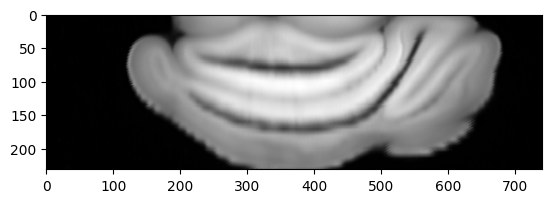

In [83]:
loaded = np.load(os.path.join(r'I:\Cerebellum_imaging_Dec2025', 'roi_polygons.npz'), allow_pickle=True)
roi_polygons = {k: loaded[k] for k in loaded.files}
atlas_template = np.load(r'I:\Cerebellum_imaging_Dec2025\Registration\atlas_template_slice51.npy')
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template, cmap='gray')
roi_masks_full = polygons_to_masks(roi_polygons, atlas_template.shape)

In [7]:
agg_data = {}
behav_train_path = r'I:\Cerebellum_imaging_Dec2025\training_data'
ca_img_path = r'I:\Cerebellum_Imaging_Dec2025'
mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AF_L3', 'AB_R2', 'J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2'] 
#mouse_ids = ['AF_L3', 'AB_R2', 'A_R2', 'A_R3','J_L2', 'AF_L2'] 
# mouse_ids = ['J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        facemap_folder = os.path.join(bhv_path, 'raw_video_data')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            try:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm1'] = {}
            mouse_data[date]['arm1']['stat'] = np.array(arm1_stat, dtype=object)
            mouse_data[date]['arm1']['table_for_img'] = pd.read_csv(arm1_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm1']['design_matrix'] = np.load(os.path.join(arm1_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
            frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
            arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
            arm1_dff_for_video = arm1_dff[:,tf_arm1_table_for_img['ruleCue_times'][0]:tf_arm1_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm1']['design_matrix']    # (T, P)
            F = arm1_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm1']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new
            mouse_data[date]['arm1']['unique_predictors_extended'] = list(unique_predictors) + ['left_choice_group', 'right_choice_group']
        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            try:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm2'] = {}
            mouse_data[date]['arm2']['stat'] = np.array(arm2_stat, dtype=object)
            mouse_data[date]['arm2']['table_for_img'] = pd.read_csv(arm2_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm2']['design_matrix'] = np.load(os.path.join(arm2_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
            frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
            arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
            arm2_dff_for_video = arm2_dff[:,tf_arm2_table_for_img['ruleCue_times'][0]:tf_arm2_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm2']['design_matrix']    # (T, P)
            F = arm2_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm2']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new


        mouse_data[date]['pupil_area'] = np.load(os.path.join(facemap_folder, 'pupil_area.npy')) # synced to table for video
        mouse_data[date]['pupil_xpos'] = np.load(os.path.join(facemap_folder, 'pupil_xpos.npy'))
        mouse_data[date]['pupil_ypos'] = np.load(os.path.join(facemap_folder, 'pupil_ypos.npy'))
        mouse_data[date]['body_motion'] = np.load(os.path.join(facemap_folder, 'bodymotion_svd.npy'))
        mouse_data[date]['face_motion'] = np.load(os.path.join(facemap_folder, 'facemotion_svd.npy'))
        mouse_data[date]['lick'] = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
        mouse_data[date]['pupil_area'] = fill_nan_with_previous(mouse_data[date]['pupil_area'])
        mouse_data[date]['pupil_xpos'] = fill_nan_with_previous(mouse_data[date]['pupil_xpos'])
        mouse_data[date]['pupil_ypos'] = fill_nan_with_previous(mouse_data[date]['pupil_ypos'])
        mouse_data[date]['table_for_video'] = pd.read_csv(bhv_path+'\\table_for_video.csv')
        mouse_data[date]['trials_table'] = pd.read_parquet(bhv_path+'\\alf\\_ibl_trials.table.pqt')
        
        bpod_trials = rawio.load_data(bhv_path, task_collection='raw_behavior_data')
        ts, pos = get_wheel_position(bhv_path, bpod_trials, task_collection='raw_behavior_data')
        interp_pos, interp_ts = wh.interpolate_position(ts, pos, freq=1000)
        wheel_moves = extract_wheel_moves(ts, pos, display=False)
        mouse_data[date]['wheel_vel'] = extract_wheel_velocity(interp_pos) # synced to trials table
        mouse_data[date]['wheel_ts'] = interp_ts
        mouse_data[date]['wheel_pos'] = interp_pos
    
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:15]
    
    
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            if 'arm1' in mouse_data[date]:
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
                tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
                arm1_bsl_psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm1_bsl_psth = get_trial_PSTH(arm1_dff, arm1_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm1_bsl_psth = arm1_bsl_psth.reshape(arm1_bsl_psth.shape[0], -1)
                arm1_bsl_mean = np.mean(arm1_bsl_psth, axis=1)
                arm1_bsl_sd = np.std(arm1_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm1_bsl_mean[np.newaxis, :, np.newaxis]) / arm1_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
            if 'arm2' in mouse_data[date]:  
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy')) 
                tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
                arm2_bsl_psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm2_bsl_psth = get_trial_PSTH(arm2_dff, arm2_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm2_bsl_psth = arm2_bsl_psth.reshape(arm2_bsl_psth.shape[0], -1)
                arm2_bsl_mean = np.mean(arm2_bsl_psth, axis=1)
                arm2_bsl_sd = np.std(arm2_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm2_bsl_mean[np.newaxis, :, np.newaxis]) / arm2_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
    agg_data[mouse] = mouse_data
    

Found 130 stim_on and 130 closed_loop events on the rotary encoder
Found 262 stim_on and 262 closed_loop events on the rotary encoder
Found 294 stim_on and 294 closed_loop events on the rotary encoder
Found 258 stim_on and 258 closed_loop events on the rotary encoder
Found 339 stim_on and 339 closed_loop events on the rotary encoder
2026-04-28 10:44:05.538 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 117657  I:\Cerebellum_Imaging_Dec2025\AE_L2\20250729_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
Found 325 stim_on and 325 closed_loop events on the rotary encoder
Found 311 stim_on and 311 closed_loop events on the rotary encoder
Found 254 stim_on and 254 closed_loop events on the rotary encoder
Found 248 stim_on and 248 closed_loop events on the rotary encoder
2026-04-28 10:46:35.102 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 

In [8]:
from scipy.optimize import linear_sum_assignment

def _date_to_int(date_str):
    """
    Extract sortable integer date from strings like:
      '20250101', '20250101_valvesilent', '20250101_valvesilent_punishsilent'
    """
    # take leading digits
    digits = []
    for ch in date_str:
        if ch.isdigit():
            digits.append(ch)
        else:
            break
    return int("".join(digits)) if digits else -1

def _infer_grid_width_from_stats(stat_list):
    max_x = 0
    for st in stat_list:
        x = np.asarray(st['xcoord_lin'])
        if x.size:
            max_x = max(max_x, int(np.max(x)))
    return max_x + 1

def _roi_lin_indices(st, W):
    x = np.asarray(st['xcoord_lin'], dtype=np.int64)
    y = np.asarray(st['ycoord_lin'], dtype=np.int64)
    lin = y * W + x
    return np.unique(lin)

def _centroid_xy(st):
    x = np.asarray(st['xcoord_lin'], dtype=np.float64)
    y = np.asarray(st['ycoord_lin'], dtype=np.float64)
    if x.size == 0:
        return np.nan, np.nan
    return float(np.mean(x)), float(np.mean(y))

def _dilate_lin_indices(lin, W, r=1):
    """
    Dilate a set of linear indices by radius r in Chebyshev distance on a W-wide grid.
    Implemented by adding offsets (dx, dy) and clipping by removing negatives (roughly).
    NOTE: We don't know H, so we can't perfectly clip y-range; but negative indices are removed,
    and huge positives usually won't occur if coords are valid and r small.
    """
    if r is None or r <= 0 or lin.size == 0:
        return lin

    # offsets for square neighborhood
    offsets = []
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            offsets.append(dy * W + dx)
    offsets = np.array(offsets, dtype=np.int64)

    dil = (lin[:, None] + offsets[None, :]).reshape(-1)
    dil = dil[dil >= 0]
    return np.unique(dil)

def _intersection_size_sorted(a, b):
    # a,b are sorted unique int arrays
    i = j = inter = 0
    na, nb = a.size, b.size
    while i < na and j < nb:
        if a[i] == b[j]:
            inter += 1
            i += 1
            j += 1
        elif a[i] < b[j]:
            i += 1
        else:
            j += 1
    return inter

def _dice_sorted_unique(a, b):
    if a.size == 0 or b.size == 0:
        return 0.0
    inter = _intersection_size_sorted(a, b)
    denom = a.size + b.size
    return (2.0 * inter / denom) if denom > 0 else 0.0

def match_day_to_reference_dice(
    ref_rois, ref_centroids,
    day_rois, day_centroids,
    dice_thresh=0.40,
    max_centroid_dist=15.0,
    area_ratio_bounds=(0.4, 2.5),
):
    """
    Hungarian 1-1 assignment maximizing Dice (minimizing 1-Dice), with gates.
    Returns list of (ref_i, day_j, dice).
    """
    n_ref = len(ref_rois)
    n_day = len(day_rois)
    if n_ref == 0 or n_day == 0:
        return []

    BIG = 1e6
    cost = np.full((n_ref, n_day), BIG, dtype=np.float64)

    for i in range(n_ref):
        a = ref_rois[i]
        ax, ay = ref_centroids[i]
        area_a = a.size

        for j in range(n_day):
            b = day_rois[j]
            bx, by = day_centroids[j]
            area_b = b.size

            # centroid gate
            if max_centroid_dist is not None:
                if not (np.isfinite(ax) and np.isfinite(bx)):
                    continue
                d = np.hypot(ax - bx, ay - by)
                if d > max_centroid_dist:
                    continue

            # area gate
            if area_ratio_bounds is not None and area_a > 0:
                lo, hi = area_ratio_bounds
                ratio = area_b / area_a
                if ratio < lo or ratio > hi:
                    continue

            dice = _dice_sorted_unique(a, b)
            if dice >= dice_thresh:
                cost[i, j] = 1.0 - dice

    row_ind, col_ind = linear_sum_assignment(cost)

    matches = []
    for i, j in zip(row_ind, col_ind):
        if cost[i, j] >= BIG / 10:
            continue
        dice = 1.0 - cost[i, j]
        matches.append((i, j, dice))
    return matches

def build_tracks_ref_anchor(
    mouse_data,
    arm='arm1',
    dice_thresh=0.40,
    max_centroid_dist=15.0,
    area_ratio_bounds=(0.4, 2.5),
    dilate_r=1,                   # <-- drift tolerance knob
):
    """
    Build ref-anchored tracks: one track per ref neuron, with per-day matched index or None.
    """
    dates = [
        d for d in mouse_data.keys()
        if d != 'training' and arm in mouse_data[d] and 'stat' in mouse_data[d][arm]
    ]
    if len(dates) == 0:
        return [], None, []

    # sort chronologically by numeric date prefix
    dates = sorted(dates, key=_date_to_int)

    # choose reference day (max neurons)
    counts = {d: len(mouse_data[d][arm]['stat']) for d in dates}
    ref_day = max(counts, key=counts.get)
    ref_stat = mouse_data[ref_day][arm]['stat']

    # infer W from ref
    W = _infer_grid_width_from_stats(ref_stat)

    # precompute ref ROIs (+ dilation) & centroids
    ref_rois = []
    ref_centroids = []
    for st in ref_stat:
        lin = _roi_lin_indices(st, W)
        lin = _dilate_lin_indices(lin, W, r=dilate_r)
        ref_rois.append(lin)
        ref_centroids.append(_centroid_xy(st))

    # initialize tracks (one per ref neuron)
    tracks = [{
        'ref_day': ref_day,
        'ref_idx': i,
        'matches': {d: None for d in dates},
        'scores':  {d: None for d in dates},   # Dice scores
    } for i in range(len(ref_rois))]

    # ref day is identity match
    for i in range(len(ref_rois)):
        tracks[i]['matches'][ref_day] = i
        tracks[i]['scores'][ref_day] = 1.0

    # match each day to ref
    for d in dates:
        if d == ref_day:
            continue
        day_stat = mouse_data[d][arm]['stat']

        day_rois = []
        day_centroids = []
        for st in day_stat:
            lin = _roi_lin_indices(st, W)
            lin = _dilate_lin_indices(lin, W, r=dilate_r)
            day_rois.append(lin)
            day_centroids.append(_centroid_xy(st))

        matches = match_day_to_reference_dice(
            ref_rois, ref_centroids,
            day_rois, day_centroids,
            dice_thresh=dice_thresh,
            max_centroid_dist=max_centroid_dist,
            area_ratio_bounds=area_ratio_bounds,
        )

        lut = {ref_i: (day_j, dice) for (ref_i, day_j, dice) in matches}
        for t in tracks:
            ref_i = t['ref_idx']
            if ref_i in lut:
                day_j, dice = lut[ref_i]
                t['matches'][d] = day_j
                t['scores'][d] = dice

    return tracks, ref_day, dates

def filter_tracks_by_coverage_and_span(tracks, dates, min_coverage=0.70, min_span=0.70):
    """
    Keep tracks present in >= min_coverage fraction of days, AND spanning >= min_span of the timeline.
    """
    if len(tracks) == 0:
        return []

    date_idx = {d: i for i, d in enumerate(dates)}
    n_days = len(dates)

    kept = []
    for t in tracks:
        present_days = [d for d in dates if t['matches'][d] is not None]
        k = len(present_days)
        coverage = k / n_days

        if k == 0:
            continue
        idxs = [date_idx[d] for d in present_days]
        span = (max(idxs) - min(idxs)) / (n_days - 1) if n_days > 1 else 1.0

        if coverage >= min_coverage and span >= min_span:
            t2 = dict(t)
            t2['coverage'] = coverage
            t2['span'] = span
            # mean Dice over present days
            scores = [t['scores'][d] for d in present_days if t['scores'][d] is not None]
            t2['mean_score'] = float(np.mean(scores)) if len(scores) else np.nan
            kept.append(t2)

    return kept

def tracks_to_match_matrices(tracks, dates, missing_val=-1):
    """
    Convert list-of-dicts tracks into matrices aligned to reference indices.
    Assumes tracks are one per ref neuron and track['ref_idx'] is unique.
    """
    ref_n = len(tracks)
    nd = len(dates)
    date_to_j = {d: j for j, d in enumerate(dates)}

    match_idx = np.full((ref_n, nd), missing_val, dtype=np.int32)
    match_score = np.full((ref_n, nd), np.nan, dtype=np.float32)

    for t in tracks:
        i = t['ref_idx']
        for d, j in date_to_j.items():
            di = t['matches'].get(d, None)
            sc = t['scores'].get(d, None)
            if di is None:
                continue
            match_idx[i, j] = int(di)
            match_score[i, j] = float(sc) if sc is not None else np.nan

    return match_idx, match_score

def compute_track_metrics_from_matrices(match_idx, match_score, dates, missing_val=-1):
    """
    match_idx: (Nref, Nd) int
    match_score: (Nref, Nd) float
    """
    Nref, Nd = match_idx.shape

    present = (match_idx != missing_val)          # bool (Nref, Nd)
    k = present.sum(axis=1)                       # (Nref,)
    coverage = k / Nd                             # (Nref,)

    # span: based on first/last present day index
    span = np.zeros(Nref, dtype=np.float32)
    span[:] = 0.0
    if Nd == 1:
        span[:] = (k > 0).astype(np.float32)
    else:
        # for each row, find min/max day index where present
        day_idx = np.arange(Nd)[None, :]          # (1, Nd)
        # mask absent as large/small for min/max
        big = 10**9
        min_j = np.where(present, day_idx, big).min(axis=1)
        max_j = np.where(present, day_idx, -big).max(axis=1)

        valid = (k > 0)
        span[valid] = (max_j[valid] - min_j[valid]) / (Nd - 1)

    # mean score over present days
    mean_score = np.full(Nref, np.nan, dtype=np.float32)
    for i in range(Nref):
        sc = match_score[i, present[i]]
        if sc.size:
            mean_score[i] = float(np.nanmean(sc))

    return coverage, span, mean_score

In [9]:
tracking_summary = {}

for mouse, mouse_data in agg_data.items():
    tracking_summary[mouse] = {}

    for arm in ('arm1', 'arm2'):
        tracks, ref_day, dates = build_tracks_ref_anchor(
            mouse_data,
            arm=arm,
            dice_thresh=0.5,
            max_centroid_dist=10.0,
            area_ratio_bounds=(0.35, 3.0),
            dilate_r=1,
        )

        if len(tracks) == 0:
            tracking_summary[mouse][arm] = {
                "ref_day": None,
                "dates": [],
                "ref_n": 0,
                "match_idx": np.zeros((0, 0), dtype=np.int32),
                "match_score": np.zeros((0, 0), dtype=np.float32),
                "kept_mask": np.zeros((0,), dtype=bool),
                "coverage": np.zeros((0,), dtype=np.float32),
                "span": np.zeros((0,), dtype=np.float32),
                "mean_score": np.zeros((0,), dtype=np.float32),
            }
            continue

        match_idx, match_score = tracks_to_match_matrices(tracks, dates, missing_val=-1)

        coverage, span, mean_score = compute_track_metrics_from_matrices(
            match_idx, match_score, dates, missing_val=-1
        )

        kept_mask = (coverage >= 0.70) & (span >= 0.70)

        tracking_summary[mouse][arm] = {
            "ref_day": ref_day,
            "dates": dates,
            "ref_n": match_idx.shape[0],
            "match_idx": match_idx,
            "match_score": match_score,
            "kept_mask": kept_mask,
            "coverage": coverage,
            "span": span,
            "mean_score": mean_score,
            "n_kept": int(kept_mask.sum()),
        }

        print(f"{mouse} {arm}: ref={ref_day}, days={len(dates)}, kept={int(kept_mask.sum())}/{match_idx.shape[0]}")

AE_L2 arm1: ref=20250821_valvesilent_punishsilent, days=8, kept=88/576
AE_L2 arm2: ref=20250624_valvesilent, days=8, kept=187/611
AE_L3 arm1: ref=20250903_valvesilent, days=12, kept=125/777
AE_L3 arm2: ref=20250701_valvesilent, days=12, kept=183/790
AF_R3 arm1: ref=20250909_valvesilent_punishsilent, days=15, kept=109/803
AF_R3 arm2: ref=20250904_valvesilent_punishsilent, days=15, kept=128/818
AF_L2 arm1: ref=20250625_valvesilent, days=10, kept=12/450
AF_L2 arm2: ref=20250618_valvesilent, days=10, kept=37/511
AF_L3 arm1: ref=20250904_valvesilent_punishsilent, days=13, kept=108/753
AF_L3 arm2: ref=20250821_valvesilent, days=13, kept=117/532
AB_R2 arm1: ref=20250715_valvesilent, days=11, kept=84/451
AB_R2 arm2: ref=20250814_valvesilent_punishsilent, days=11, kept=54/398
J_L2 arm1: ref=20241106, days=9, kept=23/345
J_L2 arm2: ref=20241106, days=8, kept=83/450
A_R2 arm1: ref=20241015, days=8, kept=82/517
A_R2 arm2: ref=20241018, days=6, kept=54/346
A_R3 arm1: ref=20240918, days=7, kept=110/

In [10]:
def get_stat_matrix_across_days(agg_data, tracking_summary, mouse, arm,
                                kept_only=False, missing_val=-1):
    """
    Returns:
      dates: list[str] length Nd
      stat_by_day: dict[date] -> list length Nref (aligned to ref index)
                  each element is either a stat dict or None
      ref_indices: numpy array of ref indices included (useful if kept_only=True)
    """
    d = tracking_summary[mouse][arm]
    dates = d["dates"]
    M = d["match_idx"]  # (Nref, Nd)

    if M.size == 0:
        return dates, {}, np.array([], dtype=int)

    ref_idx_all = np.arange(M.shape[0])

    if kept_only:
        keep = d["kept_mask"].astype(bool)
        ref_idx = ref_idx_all[keep]
        M_use = M[keep, :]          # (Nkeep, Nd)
    else:
        ref_idx = ref_idx_all
        M_use = M                   # (Nref, Nd)

    stat_by_day = {}

    for j, day in enumerate(dates):
        # allocate list in ref order (filtered order if kept_only=True)
        out = [None] * M_use.shape[0]

        if day not in agg_data[mouse] or arm not in agg_data[mouse][day]:
            stat_by_day[day] = out
            continue

        stat_arr = agg_data[mouse][day][arm]["stat"]

        idxs = M_use[:, j].astype(int)
        for i, idx in enumerate(idxs):
            if idx == missing_val:
                continue
            out[i] = stat_arr[idx]

        stat_by_day[day] = out

    return dates, stat_by_day, ref_idx

In [36]:
mouse = "AE_L3"
arm = "arm2"
dates, stat_by_day, ref_idx = get_stat_matrix_across_days(
    agg_data, tracking_summary, mouse=mouse, arm=arm, kept_only=True
)


In [99]:
def _stack_roi_pixels(stat_list):
    xs, ys = [], []
    for st in stat_list:
        if st is None:
            continue
        x = np.asarray(st['xcoord_lin'])
        y = np.asarray(st['ycoord_lin'])
        if x.size == 0:
            continue
        xs.append(x); ys.append(y)
    if not xs:
        return np.array([]), np.array([])
    return np.concatenate(xs), np.concatenate(ys)

def plot_union_overlay_day_vs_ref_matched_only(
    agg_data, tracking_summary, mouse, arm,
    stat_by_day, ref_idx,
    day,
    pad=12,
    s=1,
    alpha=0.12,
    invert_y=True,
    show_mean_score=True,
    ax=None,
    colors=None,
    label_prefix=None,
    show=True,
):
    """
    Overlay union masks for REF vs DAY, but ONLY for identities matched on `day`.

    Supports plotting multiple arms onto the same axis by passing ax.
    Returns fig, ax.
    """
    dsum = tracking_summary[mouse][arm]
    ref_day = dsum["ref_day"]
    dates = dsum["dates"]
    date_to_j = {d: j for j, d in enumerate(dates)}

    if day not in date_to_j:
        raise ValueError(f"{day} not in dates for {mouse} {arm}")
    if ref_day not in date_to_j:
        raise ValueError(f"ref_day {ref_day} not in dates for {mouse} {arm}")

    j_day = date_to_j[day]
    j_ref = date_to_j[ref_day]
    M = dsum["match_idx"]
    S = dsum.get("match_score")

    kept_n = len(ref_idx)
    day_stats_all = stat_by_day[day]

    day_stats_present = []
    ref_stats_present = []
    scores_present = []

    for k, ref_i in enumerate(ref_idx):
        day_i = int(M[ref_i, j_day])
        if day_i == -1:
            continue

        st_day = day_stats_all[k]
        if st_day is None:
            continue

        ref_i2 = int(M[ref_i, j_ref])
        if ref_i2 == -1:
            continue

        st_ref = agg_data[mouse][ref_day][arm]["stat"][ref_i2]

        day_stats_present.append(st_day)
        ref_stats_present.append(st_ref)

        if S is not None:
            sc = S[ref_i, j_day]
            if np.isfinite(sc):
                scores_present.append(float(sc))

    present_n = len(day_stats_present)
    pct = (present_n / kept_n * 100.0) if kept_n > 0 else 0.0
    mean_sc = float(np.mean(scores_present)) if (
        show_mean_score and len(scores_present) > 0
    ) else np.nan

    x_day, y_day = _stack_roi_pixels(day_stats_present)
    x_ref, y_ref = _stack_roi_pixels(ref_stats_present)

    if x_day.size == 0 or x_ref.size == 0:
        print(f"No matched identities to plot for {mouse} {arm} on {day} "
              f"(present={present_n}/{kept_n})")
        return None, ax

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 6.5))
    else:
        fig = ax.figure
    
    if colors is None:
        colors = {
            "ref": None,
            "day": None,
        }

    if label_prefix is None:
        label_prefix = arm

    ax.scatter(
        x_ref, y_ref,
        s=s,
        alpha=alpha,
        color=colors.get("ref", None),
        label=f"{label_prefix} ref {ref_day}"
    )
    ax.scatter(
        x_day, y_day,
        s=s,
        alpha=alpha,
        color=colors.get("day", None),
        label=f"{label_prefix} day {day}"
    )
    
    # update common bounds without overwriting previous arm
    xs = np.concatenate([x_ref, x_day])
    ys = np.concatenate([y_ref, y_day])

    xmin_new, xmax_new = int(xs.min()) - pad, int(xs.max()) + pad
    ymin_new, ymax_new = int(ys.min()) - pad, int(ys.max()) + pad

    if len(ax.collections) <= 2:
        ax.set_xlim(xmin_new, xmax_new)
        ax.set_ylim(ymin_new, ymax_new)
    else:
        xmin_old, xmax_old = ax.get_xlim()
        ymin_old, ymax_old = ax.get_ylim()

        ax.set_xlim(min(xmin_old, xmin_new), max(xmax_old, xmax_new))

        if invert_y:
            # y-axis may already be inverted
            ax.set_ylim(max(ymax_old, ymax_new), min(ymin_old, ymin_new))
        else:
            ax.set_ylim(min(ymin_old, ymin_new), max(ymax_old, ymax_new))

    ax.set_aspect("equal")

    if invert_y and not ax.yaxis_inverted():
        ax.invert_yaxis()

    ax.set_title(f"{mouse}: matched-only overlay, {day}")

    lines = [
        f"{arm}: {present_n}/{kept_n} ({pct:.1f}%)"
    ]
    if show_mean_score and np.isfinite(mean_sc):
        lines.append(f"{arm} mean Dice: {mean_sc:.3f}")

    # Add one textbox per call, vertically stacked
    existing_texts = len(ax.texts)
    y_text = 0.98 - existing_texts * 0.11

    ax.text(
        0.02, y_text,
        "\n".join(lines),
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\2404698860.py:177: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


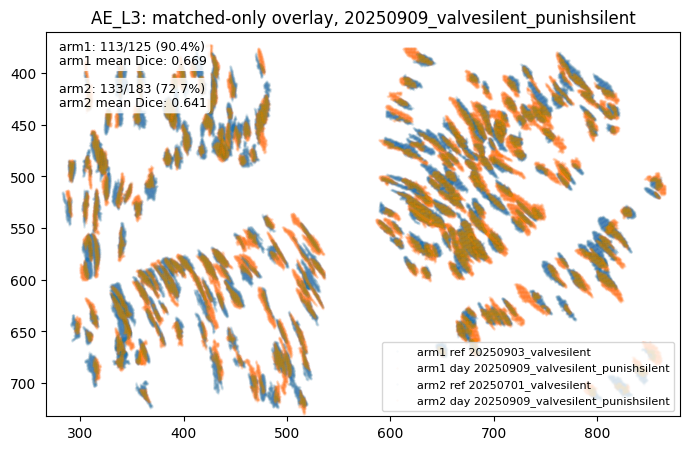

In [100]:
mouse = "AE_L3"
day = "20250909_valvesilent_punishsilent"

fig, ax = plt.subplots(figsize=(7, 7))

for arm, colors in [
    ("arm1", {"ref": "tab:blue", "day": "tab:orange"}),
    ("arm2", {"ref": "tab:blue", "day": "tab:orange"}),
]:
    dates, stat_by_day, ref_idx = get_stat_matrix_across_days(
        agg_data, tracking_summary,
        mouse=mouse,
        arm=arm,
        kept_only=True
    )

    fig, ax = plot_union_overlay_day_vs_ref_matched_only(
        agg_data, tracking_summary, mouse, arm,
        stat_by_day=stat_by_day,
        ref_idx=ref_idx,
        day=day,
        pad=15,
        s=0.1,
        alpha=0.06,
        show_mean_score=True,
        ax=ax,
        colors=colors,
        label_prefix=arm,
        show=False,
    )

plt.show()

In [102]:
len(agg_data['AE_L3']['20250909_valvesilent_punishsilent']['arm1']['stat'])

610

In [98]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_ddtracking"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"AE_L3_tracking_overlay.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"AE_L3_tracking_overlay.png"),
                dpi=300, bbox_inches='tight')

In [22]:
def assign_neuron_to_roi_coords(
    neuron,
    roi_masks_bool,      # dict[str] -> (H,W) bool
    x_key='xcoord_atlas',
    y_key='ycoord_atlas',
    frac_thresh=0.2,
):
    """
    Returns (best_roi, best_frac) or (None, 0.0) if no ROI meets thresh.
    """
    if (x_key not in neuron) or (y_key not in neuron):
        return None, 0.0

    x = np.asarray(neuron[x_key], dtype=int)
    y = np.asarray(neuron[y_key], dtype=int)
    if x.size == 0 or y.size == 0:
        return None, 0.0

    best_roi = None
    best_frac = 0.0

    for roi_name, roi_mask in roi_masks_bool.items():
        H, W = roi_mask.shape
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue

        xx = x[ok]
        yy = y[ok]
        n_pix_total = xx.size
        if n_pix_total == 0:
            continue

        n_pix_in_roi = np.count_nonzero(roi_mask[yy, xx])
        frac_in_roi = n_pix_in_roi / n_pix_total

        if frac_in_roi > best_frac:
            best_frac = frac_in_roi
            best_roi = roi_name

    if best_roi is not None and best_frac > frac_thresh:
        return best_roi, float(best_frac)
    return None, 0.0


def assign_rois_for_reference_neurons(
    stat_ref,            # list/array of neuron dicts for REF day (this arm)
    ref_indices,         # array of ref neuron indices included (e.g., kept ref idx)
    roi_masks_full,      # dict[str] -> (H,W) any dtype
    x_key='xcoord_atlas',
    y_key='ycoord_atlas',
    frac_thresh=0.2,
    roi_order=None,
):
    """
    Assign ROI for each ref neuron in `ref_indices` using REF day stat only.

    Returns:
      roi_label: (Nkeep,) object array of ROI names or None
      roi_frac:  (Nkeep,) float array (0 if None)
    """
    roi_masks_bool = {r: np.asarray(m, dtype=bool) for r, m in roi_masks_full.items()}
    if roi_order is None:
        roi_order = list(roi_masks_bool.keys())
        # keep iteration order stable
        roi_masks_bool = {r: roi_masks_bool[r] for r in roi_order}

    N = len(ref_indices)
    roi_label = np.empty(N, dtype=object)
    roi_frac = np.zeros(N, dtype=np.float32)

    for k, ref_i in enumerate(ref_indices):
        neuron = stat_ref[int(ref_i)]
        roi, frac = assign_neuron_to_roi_coords(
            neuron,
            roi_masks_bool,
            x_key=x_key, y_key=y_key,
            frac_thresh=frac_thresh
        )
        roi_label[k] = roi  # can be None
        roi_frac[k] = frac

    return roi_label, roi_frac

In [27]:
def infer_beta_length_from_arm(agg_data, tracking_summary, mouse, arm, pred):
    """
    Finds beta length by grabbing the first available neuron with pred_beta.
    """
    d = tracking_summary[mouse][arm]
    dates = d["dates"]
    M = d["match_idx"]

    for j, day in enumerate(dates):
        if day not in agg_data[mouse] or arm not in agg_data[mouse][day]:
            continue
        stat_arr = agg_data[mouse][day][arm]["stat"]
        for i in range(M.shape[0]):
            idx = M[i, j]
            if idx == -1:
                continue
            neuron = stat_arr[int(idx)]
            key = f"{pred}_beta"
            if key in neuron:
                return len(np.asarray(neuron[key]))
    raise RuntimeError(f"Could not infer beta length for {mouse} {arm} {pred}")

def extract_beta_tensor_one_arm_with_roi(
    agg_data, tracking_summary, mouse, arm, pred,
    roi_masks_full=None,
    roi_x_key='xcoord_atlas',
    roi_y_key='ycoord_atlas',
    roi_frac_thresh=0.2,
    use_kept=True,
    missing_idx=-1
):
    """
    Returns:
      dates: list[str]
      beta: (Nkeep, Nd, L) float32 with NaNs for missing
      ref_idx: (Nkeep,) ref indices
      roi_label: (Nkeep,) object (ROI name or None)  [if roi_masks_full provided]
      roi_frac: (Nkeep,) float32
    """
    d = tracking_summary[mouse][arm]
    dates = d["dates"]
    if len(dates) == 0:
        return dates, np.zeros((0, 0, 0)), np.array([], dtype=int), np.array([], dtype=object), np.array([], dtype=np.float32)

    M = d["match_idx"]  # (Nref, Nd)
    keep = d["kept_mask"].astype(bool) if (use_kept and "kept_mask" in d) else np.ones(M.shape[0], bool)
    ref_idx = np.where(keep)[0]
    M_use = M[keep, :]   # (Nkeep, Nd)
    Nkeep, Nd = M_use.shape

    # infer beta length
    beta_len = infer_beta_length_from_arm(agg_data, tracking_summary, mouse, arm, pred)
    beta = np.full((Nkeep, Nd, beta_len), np.nan, dtype=np.float32)

    # fill betas
    for j, day in enumerate(dates):
        if day not in agg_data[mouse] or arm not in agg_data[mouse][day]:
            continue
        stat_arr = agg_data[mouse][day][arm]["stat"]

        for i in range(Nkeep):
            idx = int(M_use[i, j])
            if idx == missing_idx:
                continue
            neuron = stat_arr[idx]
            b = np.asarray(neuron[f"{pred}_beta"], dtype=np.float32)
            beta[i, j, :] = b

    # ROI assignment (REF day only)
    if roi_masks_full is None:
        roi_label = np.array([None] * Nkeep, dtype=object)
        roi_frac = np.zeros(Nkeep, dtype=np.float32)
    else:
        ref_day = d["ref_day"]
        stat_ref = agg_data[mouse][ref_day][arm]["stat"]  # ref day stat array
        roi_label, roi_frac = assign_rois_for_reference_neurons(
            stat_ref=stat_ref,
            ref_indices=ref_idx,
            roi_masks_full=roi_masks_full,
            x_key=roi_x_key,
            y_key=roi_y_key,
            frac_thresh=roi_frac_thresh,
        )

    return dates, beta, ref_idx, roi_label, roi_frac

def combine_arms_beta_tensor_with_roi(
    agg_data, tracking_summary, mouse, pred,
    roi_masks_full=None,
    roi_x_key='xcoord_atlas',
    roi_y_key='ycoord_atlas',
    roi_frac_thresh=0.2,
    use_kept=True
):
    # arm1
    if "arm1" in tracking_summary[mouse]:
        d1, b1, r1, roi1, frac1 = extract_beta_tensor_one_arm_with_roi(
            agg_data, tracking_summary, mouse, "arm1", pred,
            roi_masks_full=roi_masks_full,
            roi_x_key=roi_x_key, roi_y_key=roi_y_key,
            roi_frac_thresh=roi_frac_thresh,
            use_kept=use_kept
        )
    else:
        d1, b1, r1, roi1, frac1 = [], np.zeros((0,0,0)), np.array([], int), np.array([], object), np.array([], np.float32)

    # arm2
    if "arm2" in tracking_summary[mouse]:
        d2, b2, r2, roi2, frac2 = extract_beta_tensor_one_arm_with_roi(
            agg_data, tracking_summary, mouse, "arm2", pred,
            roi_masks_full=roi_masks_full,
            roi_x_key=roi_x_key, roi_y_key=roi_y_key,
            roi_frac_thresh=roi_frac_thresh,
            use_kept=use_kept
        )
    else:
        d2, b2, r2, roi2, frac2 = [], np.zeros((0,0,0)), np.array([], int), np.array([], object), np.array([], np.float32)

    # union dates
    dates_union = sorted(set(d1) | set(d2), key=_date_to_int)
    du = len(dates_union)
    date_to_u = {d:i for i,d in enumerate(dates_union)}

    # assume beta_len same across arms for same pred; if not, raise
    L1 = b1.shape[2] if b1.size else None
    L2 = b2.shape[2] if b2.size else None
    L = L1 if L1 is not None else L2
    if (L1 is not None) and (L2 is not None) and (L1 != L2):
        raise ValueError(f"beta length mismatch arm1={L1}, arm2={L2} for pred={pred}")

    N1 = b1.shape[0]
    N2 = b2.shape[0]
    beta_u = np.full((N1 + N2, du, L), np.nan, dtype=np.float32)

    # place arm1
    for j, day in enumerate(d1):
        beta_u[:N1, date_to_u[day], :] = b1[:, j, :]

    # place arm2
    for j, day in enumerate(d2):
        beta_u[N1:, date_to_u[day], :] = b2[:, j, :]

    meta = {
        "arm": np.array(["arm1"] * N1 + ["arm2"] * N2, dtype=object),
        "ref_idx": np.concatenate([r1, r2]) if (N1 + N2) else np.array([], dtype=int),
        "roi": np.concatenate([roi1, roi2]) if (N1 + N2) else np.array([], dtype=object),
        "roi_frac": np.concatenate([frac1, frac2]) if (N1 + N2) else np.array([], dtype=np.float32),
    }

    return dates_union, beta_u, meta

In [ ]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [56]:
pred = "left_vis_stimOn_times"   # <-- example

beta_all_left_vis = {}
for mouse in mouse_ids:
    dates, beta, meta = combine_arms_beta_tensor_with_roi(
        agg_data, tracking_summary, mouse, pred,
        roi_masks_full=roi_masks_full,   # <-- your dict[str]->(H,W)
        roi_x_key='xcoord_atlas',        # or 'xcoord_lin'
        roi_y_key='ycoord_atlas',        # or 'ycoord_lin'
        roi_frac_thresh=0.2,
        use_kept=True
    )
    beta_all_left_vis[mouse] = {"dates": dates, "beta": beta, "meta": meta}

In [49]:
def plot_matched_neuron_beta_avg_heatmap_for_mouse_by_roi(
    beta_all,
    mouse,
    sort_within_roi="firstday_asc",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    unassigned_label="unassigned",
    vlim=None,
    figsize=(6, 6),
    show_roi_separators=True,
    show=True,   # <-- new
):
    dates = beta_all[mouse]["dates"]
    B = beta_all[mouse]["beta"]
    roi = beta_all[mouse]["meta"].get("roi", None)
    if roi is None:
        raise ValueError("beta_all[mouse]['meta']['roi'] not found.")

    Bavg = np.nanmean(B, axis=2)
    N = Bavg.shape[0]

    # sorting key
    if sort_within_roi == "mean":
        key_all = np.nanmean(Bavg, axis=1)
    elif sort_within_roi in ("firstday_asc", "firstday_desc"):
        key_all = Bavg[:, 0]
    elif sort_within_roi == "none":
        key_all = None
    else:
        raise ValueError("invalid sort_within_roi")

    order_parts = []
    roi_bounds = []
    cursor = 0

    def _sorted_indices_for_roi(roi_name):
        idx = np.where(roi == roi_name)[0]
        if idx.size == 0:
            return idx
        if sort_within_roi == "none":
            return idx

        subkey = key_all[idx]
        nan_mask = ~np.isfinite(subkey)
        idx_finite = idx[~nan_mask]
        idx_nan = idx[nan_mask]

        if idx_finite.size:
            fin_key = key_all[idx_finite]
            fin_order = np.argsort(fin_key)
            if sort_within_roi == "firstday_desc":
                fin_order = fin_order[::-1]
            idx_finite = idx_finite[fin_order]

        return np.concatenate([idx_finite, idx_nan])

    for r in roi_order:
        idx_r = _sorted_indices_for_roi(r)
        if idx_r.size == 0:
            continue
        order_parts.append(idx_r)
        roi_bounds.append((r, cursor, cursor + idx_r.size))
        cursor += idx_r.size

    if include_unassigned:
        idx_u = np.where(roi == None)[0]
        if idx_u.size:
            if sort_within_roi == "none":
                idx_u_sorted = idx_u
            else:
                subkey = key_all[idx_u]
                nan_mask = ~np.isfinite(subkey)
                idx_finite = idx_u[~nan_mask]
                idx_nan = idx_u[nan_mask]
                if idx_finite.size:
                    fin_order = np.argsort(key_all[idx_finite])
                    if sort_within_roi == "firstday_desc":
                        fin_order = fin_order[::-1]
                    idx_finite = idx_finite[fin_order]
                idx_u_sorted = np.concatenate([idx_finite, idx_nan])

            order_parts.append(idx_u_sorted)
            roi_bounds.append((unassigned_label, cursor, cursor + idx_u_sorted.size))
            cursor += idx_u_sorted.size

    if len(order_parts) == 0:
        raise ValueError("No neurons found.")

    order = np.concatenate(order_parts)
    Bavg_plot = Bavg[order, :]

    # color limits
    if vlim is None:
        finite = Bavg_plot[np.isfinite(Bavg_plot)]
        vmin, vmax = np.percentile(finite, [5, 95])
    else:
        vmin, vmax = vlim

    # ✅ create fig/ax explicitly
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        Bavg_plot,
        aspect='auto',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax
    )

    fig.colorbar(im, ax=ax, label="mean beta across lags")

    ax.set_xticks(np.arange(len(dates)))
    ax.set_xticklabels(dates, rotation=90, fontsize=7)
    ax.set_yticks([])
    ax.set_xlabel("day")
    ax.set_ylabel("tracked neuron (kept)")
    ax.set_title(f"{mouse}: mean beta heatmap")

    if show_roi_separators:
        for (r, start, end) in roi_bounds:
            if start > 0:
                ax.axhline(start - 0.5, linewidth=2.5, color='red')
            mid = (start + end) / 2 - 0.5
            ax.text(-0.02, mid, r,
                    transform=ax.get_yaxis_transform(),
                    ha='right', va='center', fontsize=9)

    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax, order, roi_bounds

C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\546719311.py:19: RuntimeWarning: Mean of empty slice
  Bavg = np.nanmean(B, axis=2)


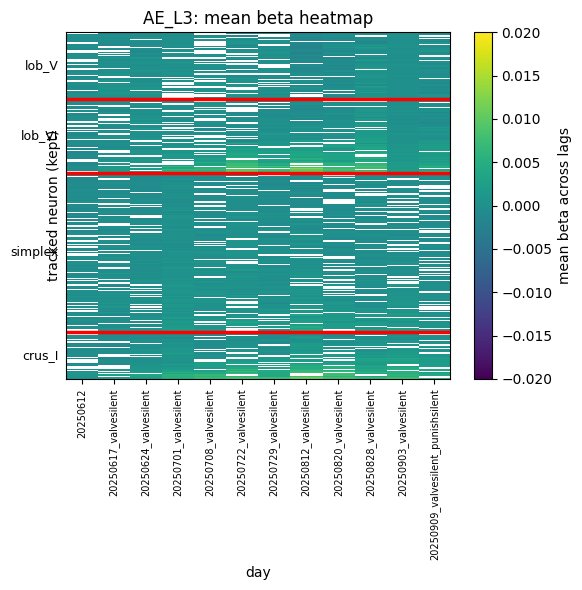

In [104]:
fig, ax, order, roi_bounds = plot_matched_neuron_beta_avg_heatmap_for_mouse_by_roi(
    beta_all_left_vis,
    mouse="AE_L3",
    sort_within_roi="mean",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    vlim = (-0.02, 0.02),
    figsize=(6, 6),
    show_roi_separators=True
)

In [51]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_ddtracking"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"AE_L3_contra_vis_beta_tracking.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"AE_L3_contra_vis_beta_tracking.png"),
                dpi=300, bbox_inches='tight')

In [65]:
def late_beta_pattern_similarity_with_session_scores_and_shuffle(
    beta_all,
    mice=None,
    late_n=5,
    n_shuffle=1000,
    min_neurons=10,
    rng_seed=0,
):
    rng = np.random.default_rng(rng_seed)

    if mice is None:
        mice = list(beta_all.keys())

    rows = []

    for mouse in mice:
        B = beta_all[mouse]["beta"]          # N x D x L
        dates = beta_all[mouse]["dates"]
        Bavg = np.nanmean(B, axis=2)         # N x D

        N, D = Bavg.shape
        if N < min_neurons or D < 3:
            continue

        late_idx = np.arange(max(0, D - late_n), D)
        if len(late_idx) < 3:
            continue

        # pairwise rho matrix
        R = np.full((len(late_idx), len(late_idx)), np.nan)

        for a in range(len(late_idx)):
            for b in range(a + 1, len(late_idx)):
                i, j = late_idx[a], late_idx[b]

                x = Bavg[:, i]
                y = Bavg[:, j]
                valid = np.isfinite(x) & np.isfinite(y)

                if np.sum(valid) < min_neurons:
                    continue

                rho, _ = spearmanr(x[valid], y[valid])
                if np.isfinite(rho):
                    R[a, b] = rho
                    R[b, a] = rho

        session_mean_rho = np.nanmean(R, axis=1)
        real_mean_rho = float(np.nanmean(session_mean_rho))

        # shuffle null at mouse-average level
        shuffle_means = []

        for _ in range(n_shuffle):
            Rshuf = np.full((len(late_idx), len(late_idx)), np.nan)

            for a in range(len(late_idx)):
                for b in range(a + 1, len(late_idx)):
                    i, j = late_idx[a], late_idx[b]

                    x = Bavg[:, i]
                    y = Bavg[:, j]
                    valid = np.isfinite(x) & np.isfinite(y)

                    if np.sum(valid) < min_neurons:
                        continue

                    xv = x[valid]
                    yv = y[valid]
                    yv_shuf = rng.permutation(yv)

                    rho, _ = spearmanr(xv, yv_shuf)
                    if np.isfinite(rho):
                        Rshuf[a, b] = rho
                        Rshuf[b, a] = rho

            shuf_session_mean = np.nanmean(Rshuf, axis=1)
            shuffle_means.append(np.nanmean(shuf_session_mean))

        shuffle_means = np.asarray(shuffle_means)

        rows.append({
            "mouse": mouse,
            "n_neurons": int(N),
            "n_days": int(D),
            "late_dates": [dates[i] for i in late_idx],
            "late_idx": late_idx,
            "rho_matrix": R,
            "session_mean_rho": session_mean_rho,
            "real_mean_rho": real_mean_rho,
            "shuffle_mean": float(np.nanmean(shuffle_means)),
            "shuffle_sd": float(np.nanstd(shuffle_means)),
            "shuffle_vals": shuffle_means,
            "shuffle_p": float((np.sum(shuffle_means >= real_mean_rho) + 1) / (len(shuffle_means) + 1)),
        })

    return rows

In [68]:
def plot_late_beta_pattern_similarity_session_scores(
    rows,
    title="Left visual tuning pattern stability after emergence",
    figsize=(5, 4),
    show=True,
):
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(rows))

    # extract values
    real_mean = np.array([r["real_mean_rho"] for r in rows])
    real_sd = np.array([
        np.nanstd(r["session_mean_rho"]) for r in rows
    ])

    shuf = np.array([r["shuffle_mean"] for r in rows])
    shuf_sd = np.array([r["shuffle_sd"] for r in rows])

    # --- individual session points (ALL gray)
    for xi, r in zip(x, rows):
        vals = np.asarray(r["session_mean_rho"], dtype=float)

        jitter = np.linspace(-0.12, 0.12, len(vals)) if len(vals) > 1 else [0]

        ax.scatter(
            xi + jitter,
            vals,
            s=20,
            color="gray",
            alpha=0.35,
            zorder=1,
            label="late sessions" if xi == 0 else None
        )

    # --- shuffle (gray, slightly darker)
    ax.errorbar(
        x,
        shuf,
        yerr=shuf_sd,
        fmt="o",
        capsize=3,
        color="black",
        alpha=0.6,
        label="shuffle",
        zorder=2,
    )

    # --- real (highlighted)
    ax.errorbar(
        x,
        real_mean,
        yerr=real_sd,
        fmt="D",
        capsize=4,
        color="tab:red",
        label="real",
        zorder=3,
    )

    ax.axhline(0, color="k", linewidth=1, alpha=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels([r["mouse"] for r in rows], rotation=45, ha="right")
    ax.set_ylabel("Mean Spearman rho\nwith other late sessions")
    ax.set_title(title)

    ax.legend(frameon=False, fontsize=8)

    # stats
    if len(real_mean) >= 3:
        from scipy.stats import wilcoxon

        _, p_vs_shuffle = wilcoxon(real_mean - shuf)

        ax.text(
            0.05, 0.95,
            f"median real = {np.nanmedian(real_mean):.2f}\n"
            f"real vs shuffle p = {p_vs_shuffle:.3g}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                alpha=0.85,
                edgecolor="none"
            )
        )

    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

In [72]:
rows = late_beta_pattern_similarity_with_session_scores_and_shuffle(
    beta_all_left_vis,
    late_n=5,
    n_shuffle=1000,
    min_neurons=10,
    rng_seed=0,
)



C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\2807435191.py:19: RuntimeWarning: Mean of empty slice
  Bavg = np.nanmean(B, axis=2)         # N x D
C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\2807435191.py:48: RuntimeWarning: Mean of empty slice
  session_mean_rho = np.nanmean(R, axis=1)
C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\2807435191.py:77: RuntimeWarning: Mean of empty slice
  shuf_session_mean = np.nanmean(Rshuf, axis=1)


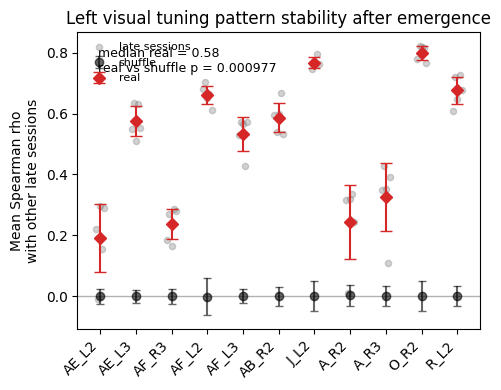

In [73]:
fig, ax = plot_late_beta_pattern_similarity_session_scores(rows, show=False)

In [74]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_ddtracking"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"AE_L3_contra_vis_beta_spearman.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"AE_L3_contra_vis_beta_spearman.png"),
                dpi=300, bbox_inches='tight')

In [75]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

TypeError: string indices must be integers

In [86]:
mouse_data.keys()

dict_keys(['20250612', '20250617_valvesilent', '20250624_valvesilent', '20250701_valvesilent', '20250708_valvesilent', '20250722_valvesilent', '20250729_valvesilent', '20250812_valvesilent', '20250820_valvesilent', '20250828_valvesilent', '20250903_valvesilent', '20250909_valvesilent_punishsilent', 'training'])

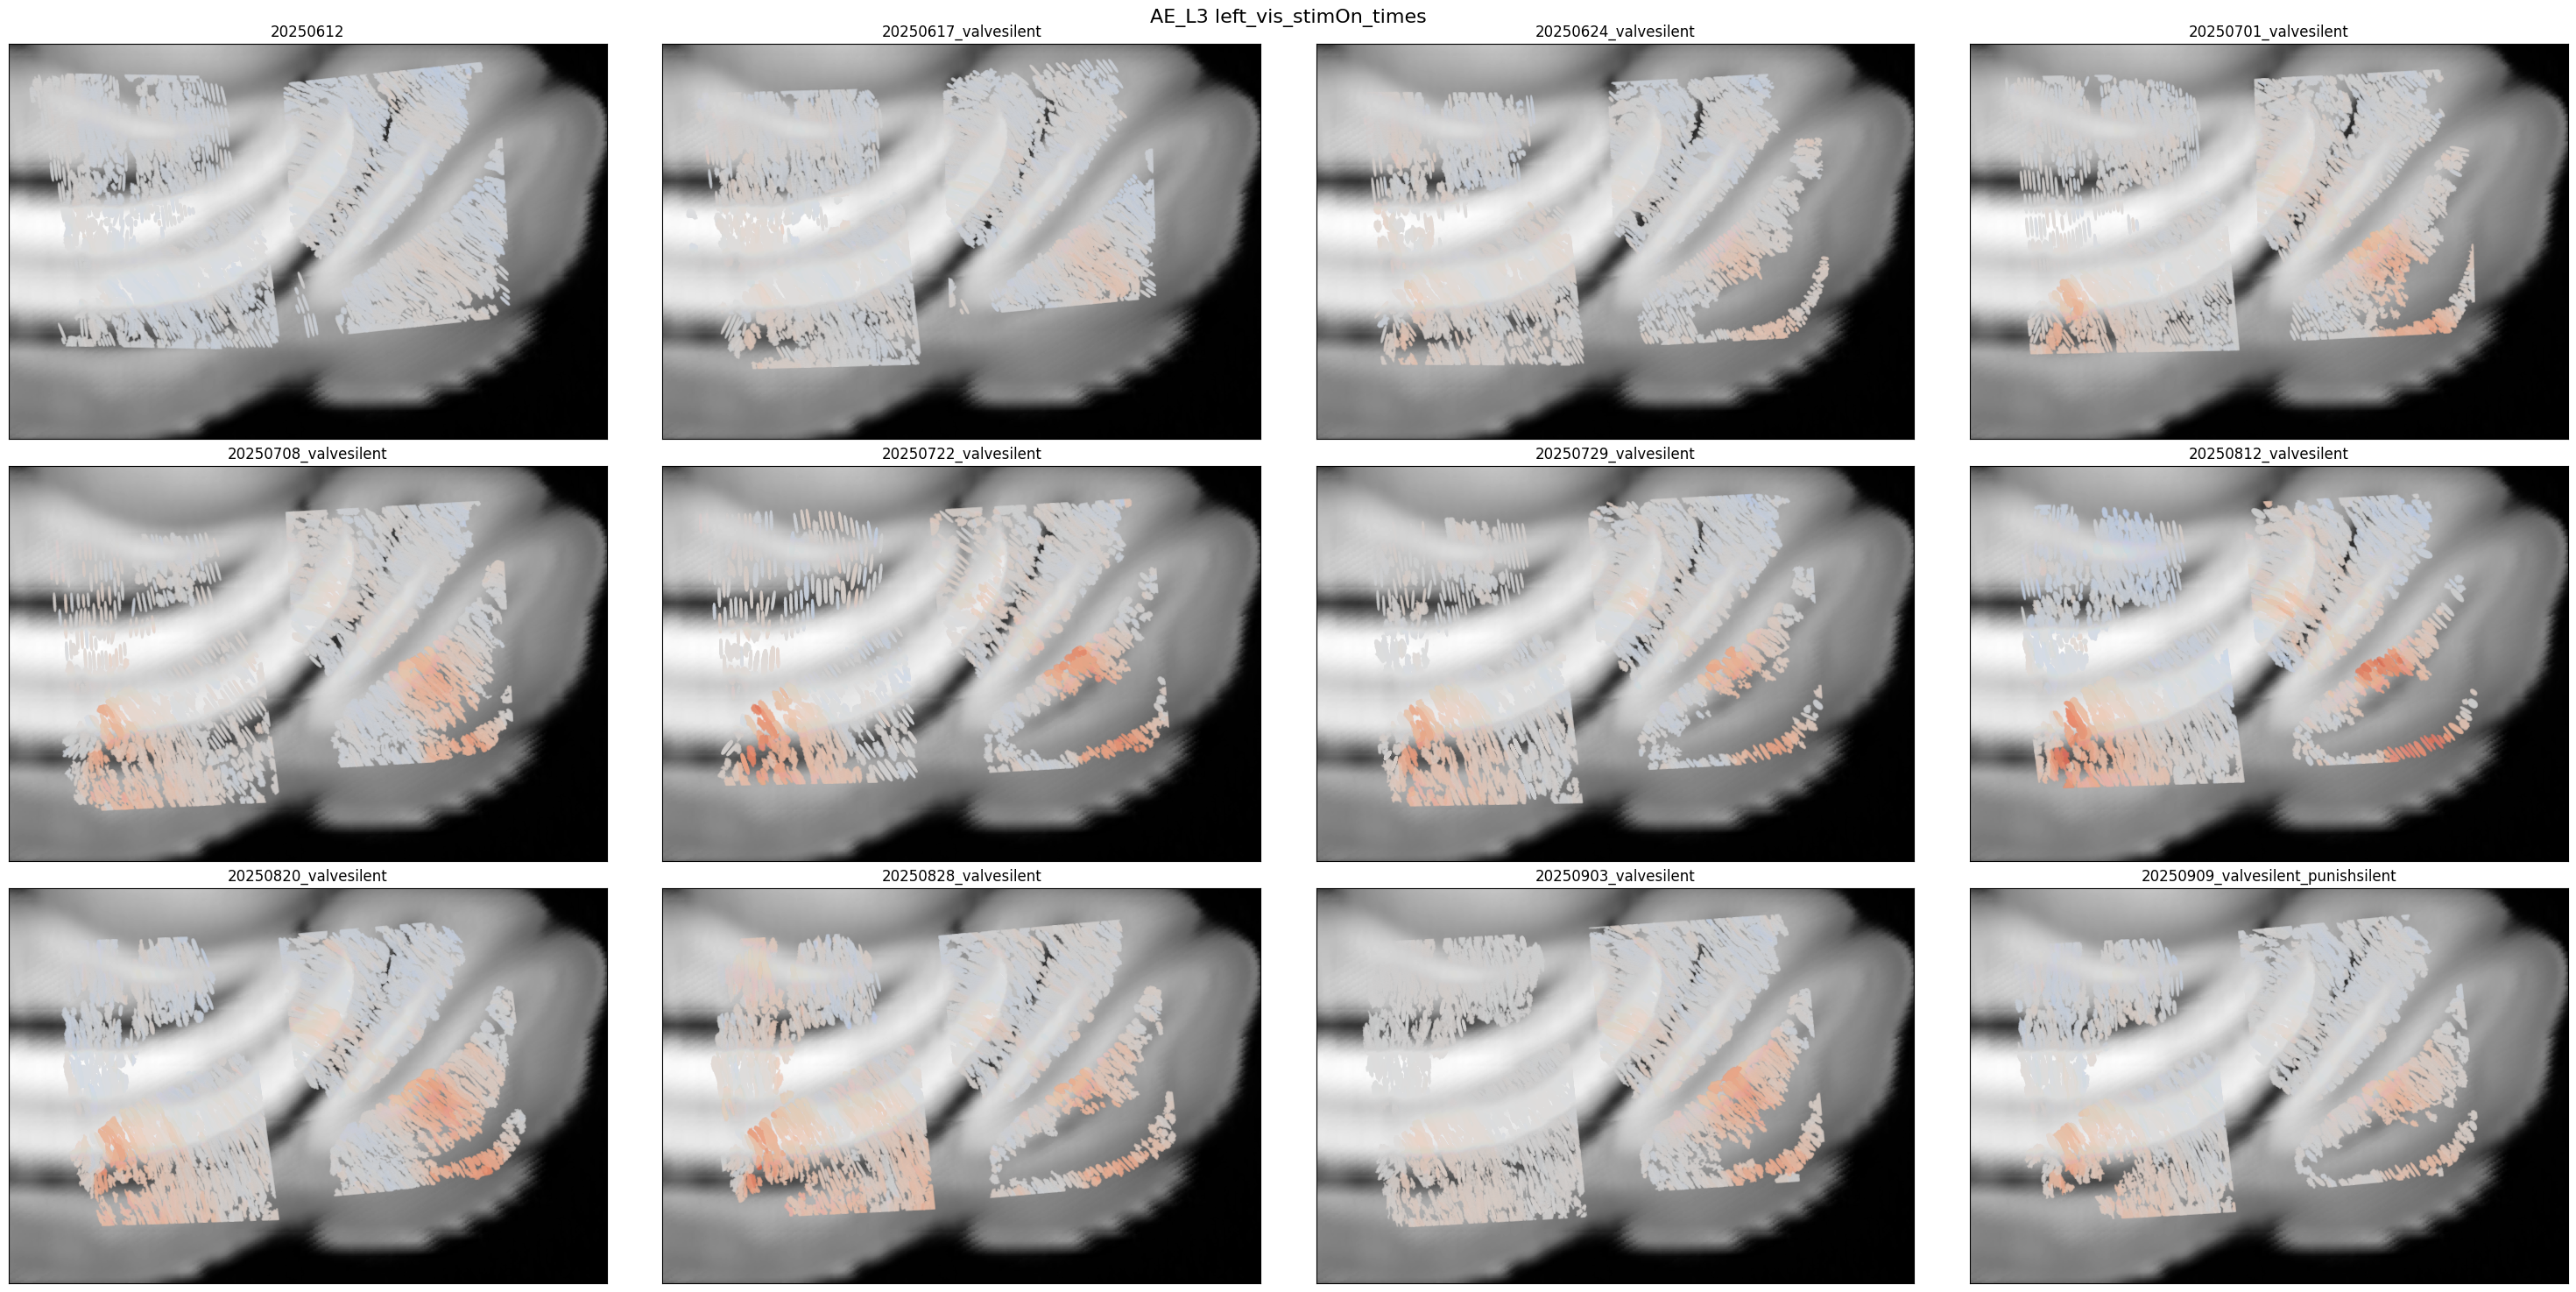

In [92]:
pred = unique_predictors[2]
pred_idx = [i for i, name in enumerate(predictors) if pred in name]

mouse_id = "AE_L3"
mouse_data = agg_data[mouse_id]

fig, axes = plt.subplots(3, 4, figsize=(30, 15))
fig.suptitle(mouse_id + ' ' + pred, fontsize=16)

sc = None  # <-- store one scatter for colorbar

x_start, x_end = 330, 680

for dayi, date in enumerate(mouse_data.keys()):
    if date == 'training':
        continue

    ax = axes[dayi // 4, dayi % 4]

    ax.imshow(atlas_template[:, x_start:x_end], cmap='gray')
    ax.set_title(date)
    ax.set_xticks([])
    ax.set_yticks([])

    if 'arm1' in mouse_data[date]:
        for neuron in mouse_data[date]['arm1']['stat']:
            resp_beta = np.mean(neuron['beta'][pred_idx])

            x = neuron['xcoord_atlas'] - x_start
            y = neuron['ycoord_atlas']

            sc = ax.scatter(
                x, y,
                c=np.repeat(resp_beta, len(x)),
                cmap='coolwarm',
                vmin=-0.02,
                vmax=0.02,
                s=0.001
            )

    if 'arm2' in mouse_data[date]:
        for neuron in mouse_data[date]['arm2']['stat']:
            resp_beta = np.mean(neuron['beta'][pred_idx])

            x = neuron['xcoord_atlas'] - x_start
            y = neuron['ycoord_atlas']

            sc = ax.scatter(
                x, y,
                c=np.repeat(resp_beta, len(x)),
                cmap='coolwarm',
                vmin=-0.02,
                vmax=0.02,
                s=0.001
            )

# ✅ add ONE shared colorbar
# cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.6)
# cbar.set_label("mean beta")

fig.tight_layout()

In [93]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_ddtracking"
os.makedirs(svg_out_dir, exist_ok=True)

# fig.savefig(
#     os.path.join(svg_out_dir,f"AE_L3_contra_vis_beta_topo.svg"),
#     format='svg',
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True,   # optional: removes white background
#     metadata={'Creator': 'Matplotlib'}
# )

fig.savefig(os.path.join(svg_out_dir, f"AE_L3_contra_vis_beta_topo.png"),
                dpi=300, bbox_inches='tight')

C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\2442180419.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm")


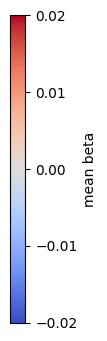

In [94]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm

# define range
vmin, vmax = -0.02, 0.02
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = cm.get_cmap("coolwarm")

# create figure
fig, ax = plt.subplots(figsize=(2, 5))

# create a ScalarMappable (no data needed)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# draw colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("mean beta")
cbar.set_ticks([-0.02, -0.01, 0, 0.01, 0.02])

# remove axis
ax.remove()

plt.tight_layout()
plt.show()

In [95]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_ddtracking"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"colorbar.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)


In [ ]:
def extract_uev_tensor_one_arm_with_roi(
    agg_data, tracking_summary, mouse, arm, pred_name, unique_predictors,
    roi_masks_full=None,
    roi_x_key='xcoord_atlas',
    roi_y_key='ycoord_atlas',
    roi_frac_thresh=0.2,
    use_kept=True,
    missing_idx=-1,
    uev_key="unique_explained_variance",
):
    """
    Extract unique explained variance (scalar) for one predictor across days for one arm,
    aligned in reference-neuron space via tracking_summary[mouse][arm]["match_idx"].

    Returns:
      dates: list[str]
      uev: (Nkeep, Nd) float32 with NaNs for missing
      ref_idx: (Nkeep,) ref indices
      roi_label: (Nkeep,) object (ROI name or None)  [if roi_masks_full provided]
      roi_frac: (Nkeep,) float32
    """
    d = tracking_summary[mouse][arm]
    dates = d["dates"]
    if len(dates) == 0:
        return (
            dates,
            np.zeros((0, 0), dtype=np.float32),
            np.array([], dtype=int),
            np.array([], dtype=object),
            np.array([], dtype=np.float32),
        )

    # predictor index
    try:
        unique_pred_idx = unique_predictors.index(pred_name)
    except ValueError as e:
        raise ValueError(f"pred_name='{pred_name}' not found in unique_predictors") from e

    M = d["match_idx"]  # (Nref, Nd)
    keep = d["kept_mask"].astype(bool) if (use_kept and "kept_mask" in d) else np.ones(M.shape[0], bool)
    ref_idx = np.where(keep)[0]
    M_use = M[keep, :]  # (Nkeep, Nd)
    Nkeep, Nd = M_use.shape

    uev = np.full((Nkeep, Nd), np.nan, dtype=np.float32)

    # fill
    md = agg_data.get(mouse, {})
    for j, day in enumerate(dates):
        if day not in md or arm not in md[day]:
            continue
        stat_arr = md[day][arm]["stat"]

        for i in range(Nkeep):
            idx = int(M_use[i, j])
            if idx == missing_idx:
                continue

            neuron = stat_arr[idx]
            if uev_key not in neuron:
                continue

            arr = np.asarray(neuron[uev_key])
            # be robust to list/np.array
            if unique_pred_idx >= arr.shape[0]:
                continue

            val = arr[unique_pred_idx]
            # cast; allow nan
            uev[i, j] = np.float32(val)

    # ROI assignment (REF day only)
    if roi_masks_full is None:
        roi_label = np.array([None] * Nkeep, dtype=object)
        roi_frac = np.zeros(Nkeep, dtype=np.float32)
    else:
        ref_day = d["ref_day"]
        stat_ref = agg_data[mouse][ref_day][arm]["stat"]  # ref day stat array
        roi_label, roi_frac = assign_rois_for_reference_neurons(
            stat_ref=stat_ref,
            ref_indices=ref_idx,
            roi_masks_full=roi_masks_full,
            x_key=roi_x_key,
            y_key=roi_y_key,
            frac_thresh=roi_frac_thresh,
        )

    return dates, uev, ref_idx, roi_label, roi_frac


def combine_arms_uev_tensor_with_roi(
    agg_data, tracking_summary, mouse, pred_name, unique_predictors,
    roi_masks_full=None,
    roi_x_key='xcoord_atlas',
    roi_y_key='ycoord_atlas',
    roi_frac_thresh=0.2,
    use_kept=True,
    uev_key="unique_explained_variance",
):
    """
    Combine arm1 + arm2 UEV tensors by:
      - taking union of dates (sorted by _date_to_int)
      - stacking neurons (arm1 neurons first, then arm2)
      - placing values into union-date index, NaN where missing

    Returns:
      dates_union: list[str]
      uev_u: (N1+N2, du) float32
      meta: dict with 'arm','ref_idx','roi','roi_frac'
    """
    # arm1
    if "arm1" in tracking_summary.get(mouse, {}):
        d1, u1, r1, roi1, frac1 = extract_uev_tensor_one_arm_with_roi(
            agg_data, tracking_summary, mouse, "arm1", pred_name, unique_predictors,
            roi_masks_full=roi_masks_full,
            roi_x_key=roi_x_key, roi_y_key=roi_y_key,
            roi_frac_thresh=roi_frac_thresh,
            use_kept=use_kept,
            uev_key=uev_key,
        )
    else:
        d1, u1, r1, roi1, frac1 = [], np.zeros((0, 0), dtype=np.float32), np.array([], int), np.array([], object), np.array([], np.float32)

    # arm2
    if "arm2" in tracking_summary.get(mouse, {}):
        d2, u2, r2, roi2, frac2 = extract_uev_tensor_one_arm_with_roi(
            agg_data, tracking_summary, mouse, "arm2", pred_name, unique_predictors,
            roi_masks_full=roi_masks_full,
            roi_x_key=roi_x_key, roi_y_key=roi_y_key,
            roi_frac_thresh=roi_frac_thresh,
            use_kept=use_kept,
            uev_key=uev_key,
        )
    else:
        d2, u2, r2, roi2, frac2 = [], np.zeros((0, 0), dtype=np.float32), np.array([], int), np.array([], object), np.array([], np.float32)

    # union dates
    dates_union = sorted(set(d1) | set(d2), key=_date_to_int)
    du = len(dates_union)
    date_to_u = {d: i for i, d in enumerate(dates_union)}

    N1 = u1.shape[0]
    N2 = u2.shape[0]
    uev_u = np.full((N1 + N2, du), np.nan, dtype=np.float32)

    # place arm1
    for j, day in enumerate(d1):
        uev_u[:N1, date_to_u[day]] = u1[:, j]  # (N1,)

    # place arm2
    for j, day in enumerate(d2):
        uev_u[N1:, date_to_u[day]] = u2[:, j]  # (N2,)

    meta = {
        "arm": np.array(["arm1"] * N1 + ["arm2"] * N2, dtype=object),
        "ref_idx": np.concatenate([r1, r2]) if (N1 + N2) else np.array([], dtype=int),
        "roi": np.concatenate([roi1, roi2]) if (N1 + N2) else np.array([], dtype=object),
        "roi_frac": np.concatenate([frac1, frac2]) if (N1 + N2) else np.array([], dtype=np.float32),
    }

    return dates_union, uev_u, meta

In [ ]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [ ]:
pred = "face"   # <-- example

uev_all = {}
for mouse in mouse_ids:
    dates, UEV, meta = combine_arms_uev_tensor_with_roi(
        agg_data, tracking_summary, mouse, pred, unique_predictors,
        roi_masks_full=roi_masks_full,
        roi_x_key='xcoord_atlas',
        roi_y_key='ycoord_atlas',
        roi_frac_thresh=0.2,
        use_kept=True)
    uev_all[mouse] = {"dates": dates, "uev": UEV, "meta": meta}

In [ ]:
def plot_matched_neuron_uev_heatmap_for_mouse_by_roi(
    uev_all,
    mouse,
    sort_within_roi="firstday_asc",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    unassigned_label="unassigned",
    vlim=None,
    figsize=(6, 6),
    show_roi_separators=True,
    cbar_label="unique explained variance",
):
    """
    Heatmap of UEV (unique explained variance) across days with rows grouped by ROI
    and sorted within each ROI.

    Expected input format (mirrors your beta_all structure):
      uev_all[mouse]["dates"] -> list[str]
      uev_all[mouse]["uev"]   -> (N_ids, N_days) float (NaN for missing)
      uev_all[mouse]["meta"]["roi"] -> (N_ids,) object array of ROI labels (or None)

    Args:
      sort_within_roi: {'none','mean','firstday_asc','firstday_desc'}
      roi_order: tuple/list of ROI names in the order to appear top->bottom
      include_unassigned: if True, append neurons with roi==None at bottom
      show_roi_separators: draw horizontal lines + ROI labels at block centers
      vlim: (vmin, vmax) or None -> percentile-based from finite values
    Returns:
      order: np.ndarray of row indices into the original (arm1+arm2 concatenated) identity list
      roi_bounds: list of (roi_name, start_row, end_row_exclusive) in the plotted heatmap
    """
    dates = uev_all[mouse]["dates"]
    U = uev_all[mouse]["uev"]  # (N_ids, N_days)
    roi = uev_all[mouse]["meta"].get("roi", None)
    if roi is None:
        raise ValueError("uev_all[mouse]['meta']['roi'] not found. Did you add ROI assignment to meta?")

    U = np.asarray(U)
    if U.ndim != 2:
        raise ValueError(f"uev_all[mouse]['uev'] must be 2D (N_ids, N_days), got shape {U.shape}")

    N = U.shape[0]

    # define key for sorting within ROI
    if sort_within_roi == "mean":
        key_all = np.nanmean(U, axis=1)     # (N,)
    elif sort_within_roi in ("firstday_asc", "firstday_desc"):
        key_all = U[:, 0]                   # (N,)
    elif sort_within_roi == "none":
        key_all = None
    else:
        raise ValueError("sort_within_roi must be one of {'none','mean','firstday_asc','firstday_desc'}")

    order_parts = []
    roi_bounds = []
    cursor = 0

    def _sorted_indices_for_roi(roi_name):
        idx = np.where(roi == roi_name)[0]
        if idx.size == 0:
            return idx
        if sort_within_roi == "none":
            return idx

        subkey = key_all[idx]
        nan_mask = ~np.isfinite(subkey)

        idx_finite = idx[~nan_mask]
        idx_nan = idx[nan_mask]

        if idx_finite.size:
            fin_key = key_all[idx_finite]
            fin_order = np.argsort(fin_key)  # ascending
            if sort_within_roi == "firstday_desc":
                fin_order = fin_order[::-1]
            idx_finite = idx_finite[fin_order]

        return np.concatenate([idx_finite, idx_nan])

    # ROIs in requested order
    for r in roi_order:
        idx_r = _sorted_indices_for_roi(r)
        if idx_r.size == 0:
            continue
        order_parts.append(idx_r)
        roi_bounds.append((r, cursor, cursor + idx_r.size))
        cursor += idx_r.size

    # optional: append unassigned
    if include_unassigned:
        idx_u = np.where(roi == None)[0]
        if idx_u.size:
            if sort_within_roi == "none":
                idx_u_sorted = idx_u
            else:
                subkey = key_all[idx_u]
                nan_mask = ~np.isfinite(subkey)

                idx_finite = idx_u[~nan_mask]
                idx_nan = idx_u[nan_mask]

                if idx_finite.size:
                    fin_order = np.argsort(key_all[idx_finite])
                    if sort_within_roi == "firstday_desc":
                        fin_order = fin_order[::-1]
                    idx_finite = idx_finite[fin_order]

                idx_u_sorted = np.concatenate([idx_finite, idx_nan])

            order_parts.append(idx_u_sorted)
            roi_bounds.append((unassigned_label, cursor, cursor + idx_u_sorted.size))
            cursor += idx_u_sorted.size

    if len(order_parts) == 0:
        raise ValueError(f"No neurons found in requested ROIs for mouse={mouse}")

    order = np.concatenate(order_parts)
    U_plot = U[order, :]

    # color limits
    if vlim is None:
        finite = U_plot[np.isfinite(U_plot)]
        if finite.size == 0:
            raise ValueError("No finite UEV values to plot.")
        vmin, vmax = np.percentile(finite, [5, 95])
    else:
        vmin, vmax = vlim

    plt.figure(figsize=figsize)
    im = plt.imshow(U_plot, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    plt.colorbar(im, label=cbar_label)
    plt.xticks(np.arange(len(dates)), dates, rotation=90, fontsize=7)
    plt.yticks([])
    plt.xlabel("day")
    plt.ylabel("tracked neuron (kept)")
    plt.title(f"{mouse}: UEV heatmap (grouped by ROI, sorted within ROI)")

    if show_roi_separators:
        ax = plt.gca()
        for (r, start, end) in roi_bounds:
            if start > 0:
                ax.axhline(start - 0.5, linewidth=2.5, color="red")
            mid = (start + end) / 2 - 0.5
            ax.text(
                -0.02, mid, r,
                transform=ax.get_yaxis_transform(),
                ha="right", va="center", fontsize=9
            )

    plt.tight_layout()
    plt.show()

    return order, roi_bounds

In [ ]:
uev_all['AE_L2']['uev'].shape

(448, 8)

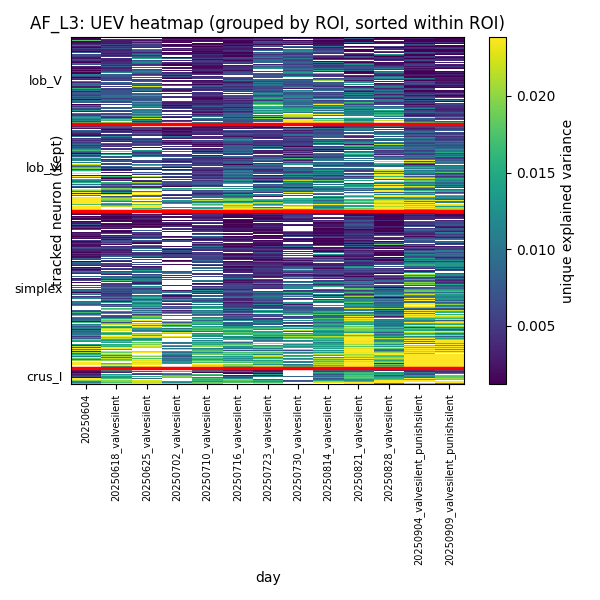

In [ ]:
order, roi_bounds = plot_matched_neuron_uev_heatmap_for_mouse_by_roi(
    uev_all, mouse="AF_L3", sort_within_roi="mean"
)

In [ ]:
def _flatten_uev_within_neuron_demean(U):
    """
    U: (N_neurons, N_days) with NaNs allowed
    Returns: 1D vector of length N_neurons * N_days, after per-neuron demeaning.
    """
    U = np.asarray(U, dtype=float)
    mu = np.nanmean(U, axis=1, keepdims=True)   # (N,1)
    Uc = U - mu
    return Uc.reshape(-1)

def _corrcoef_pairwise_nan(x, y, min_pairs=10):
    """
    Pearson correlation with pairwise NaN removal.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if int(m.sum()) < int(min_pairs):
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])





# ---------- correlation matrix per mouse (demeaned-within-neuron, flattened) ----------
def uev_pred_corr_matrix_demean_flatten(
    uev_by_pred, mouse, predictor_names, min_pairs=10
):
    """
    Returns:
      R: (P,P) correlation matrix across predictors for one mouse,
         using within-neuron demeaned, flattened UEV vectors.
    """
    P = len(predictor_names)

    flat = {}
    for pred in predictor_names:
        U = uev_by_pred[pred][mouse]["uev"]  # (N_neurons, N_days)
        flat[pred] = _flatten_uev_within_neuron_demean(U)

    R = np.full((P, P), np.nan, dtype=float)
    for i, pi in enumerate(predictor_names):
        xi = flat[pi]
        for j in range(i, P):
            pj = predictor_names[j]
            r = _corrcoef_pairwise_nan(xi, flat[pj], min_pairs=min_pairs)
            R[i, j] = r
            R[j, i] = r
    return R

In [ ]:
def plot_predictor_correlation_matrix(
    R,
    predictor_names,
    title=None,
    vlim=(-1.0, 1.0),
    cmap="coolwarm",
    figsize=None,
    show_values=False,
    value_fmt=".2f",
):
    """
    Plot a predictor × predictor correlation matrix.

    Args:
      R: (P, P) array
      predictor_names: list[str] length P
      title: optional title string
      vlim: (vmin, vmax) for color scale (default (-1,1))
      cmap: matplotlib colormap
      figsize: tuple or None -> auto scale with P
      show_values: if True, write r values in each cell
    """
    R = np.asarray(R)
    P = R.shape[0]
    assert R.shape == (P, P)

    if figsize is None:
        figsize = (0.5 * P + 3, 0.5 * P + 3)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(R, vmin=vlim[0], vmax=vlim[1], cmap=cmap)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("UEV correlation (within-neuron demeaned)")

    ax.set_xticks(np.arange(P))
    ax.set_yticks(np.arange(P))
    ax.set_xticklabels(predictor_names, rotation=45, ha="right")
    ax.set_yticklabels(predictor_names)

    ax.set_xlabel("predictor")
    ax.set_ylabel("predictor")

    if title is not None:
        ax.set_title(title)

    # optional grid
    ax.set_xticks(np.arange(-0.5, P, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, P, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # optional numeric annotations
    if show_values:
        for i in range(P):
            for j in range(P):
                if np.isfinite(R[i, j]):
                    ax.text(
                        j, i, format(R[i, j], value_fmt),
                        ha="center", va="center",
                        fontsize=8,
                        color="black" if abs(R[i, j]) < 0.6 else "white",
                    )

    plt.tight_layout()
    plt.show()

    return ax

In [ ]:
# ---------- build uev_by_pred[pred][mouse] = {"dates","uev","meta"} ----------
uev_by_pred = {}

for pred in unique_predictors:
    uev_by_pred[pred] = {}
    for mouse in mouse_ids:
        dates, UEV, meta = combine_arms_uev_tensor_with_roi(
            agg_data, tracking_summary, mouse, pred, unique_predictors,
            roi_masks_full=roi_masks_full,
            roi_x_key='xcoord_atlas',
            roi_y_key='ycoord_atlas',
            roi_frac_thresh=0.2,
            use_kept=True
        )
        uev_by_pred[pred][mouse] = {"dates": dates, "uev": UEV, "meta": meta}

In [105]:
reward_mouse_ids = ["AE_L2", "AE_L3", "AF_L2", "AF_L3","AB_R2", "AF_R3"]

In [ ]:
agg_R = []
for mouse in reward_mouse_ids:

    R = uev_pred_corr_matrix_demean_flatten(
        uev_by_pred,
        mouse=mouse,
        predictor_names=unique_predictors,
        min_pairs=10
    )
    agg_R.append(R)
agg_R = np.array(agg_R)  # (N_mice, P, P)

In [ ]:
plot_predictor_correlation_matrix(
    np.mean(agg_R, axis=0),
    # uev_pred_corr_matrix_demean_flatten(
    #     uev_by_pred,
    #     mouse='AE_L3',
    #     predictor_names=unique_predictors,
    #     min_pairs=10
    # ),
    predictor_names=unique_predictors,
    title="Group mean: UEV predictor correlation (within-neuron demeaned)",
)

In [119]:
def early_late_delta(beta_tensor, early_n=3, late_n=3):
    """
    beta_tensor: (N_ids, N_days, L)
    Returns (N_ids,) delta averaged over lags: late_mean - early_mean
    """
    Bavg = np.nanmean(beta_tensor, axis=2)  # (N_ids, N_days)
    early = np.nanmean(Bavg[:, :early_n], axis=1)
    late  = np.nanmean(Bavg[:, -late_n:], axis=1)
    return late - early


def pooled_points_by_roi(
    beta_all_A, beta_all_B, mouse_ids,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=3, late_n=3,
):
    """
    Returns dict roi -> (x, y) pooled across mice, where:
      x = ΔA, y = ΔB
    """
    pts = {r: ([], []) for r in roi_order}
    if include_unassigned:
        pts["unassigned"] = ([], [])

    for mouse in mouse_ids:
        BA = beta_all_A[mouse]["beta"]
        BB = beta_all_B[mouse]["beta"]
        if BA.shape[:2] != BB.shape[:2]:
            raise ValueError(f"{mouse}: A and B tensors must match in N_ids and N_days")

        roi = np.asarray(beta_all_A[mouse]["meta"].get("roi", None), dtype=object)
        if roi is None:
            raise ValueError(f"{mouse}: ROI labels missing in beta_all_A[mouse]['meta']['roi']")

        dA = early_late_delta(BA, early_n=early_n, late_n=late_n)
        dB = early_late_delta(BB, early_n=early_n, late_n=late_n)

        ok = np.isfinite(dA) & np.isfinite(dB)
        dA = dA[ok]
        dB = dB[ok]
        roi_ok = roi[ok]

        for rname in roi_order:
            m = (roi_ok == rname)
            if np.any(m):
                pts[rname][0].append(dA[m])
                pts[rname][1].append(dB[m])

        if include_unassigned:
            m = (roi_ok == None)
            if np.any(m):
                pts["unassigned"][0].append(dA[m])
                pts["unassigned"][1].append(dB[m])

    # concatenate
    out = {}
    for rname, (xs, ys) in pts.items():
        if len(xs) == 0:
            out[rname] = (np.array([]), np.array([]))
        else:
            out[rname] = (np.concatenate(xs), np.concatenate(ys))
    return out


def plot_pooled_delta_scatter_by_roi(
    beta_all_A, beta_all_B, mouse_ids,
    label_A="Predictor A",
    label_B="Predictor B",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=3, late_n=3,
    min_points=20,
    s=10,
    alpha=0.5,
    add_reference_lines=True,
):
    pooled = pooled_points_by_roi(
        beta_all_A, beta_all_B, mouse_ids,
        roi_order=roi_order,
        include_unassigned=include_unassigned,
        early_n=early_n, late_n=late_n
    )

    # --- ROI color map ---
    ROI_COLOR_MAP = {
        "lob_V": plt.cm.Purples(0.7),
        "lob_VI": plt.cm.Oranges(0.7),
        "simplex": plt.cm.Reds(0.7),
        "crus_I": plt.cm.Blues(0.7),
        "unassigned": "gray",
    }

    results = {}
    rois = list(roi_order) + (["unassigned"] if include_unassigned else [])

    n_rois = len(rois)
    n_cols = len(rois)
    n_rows = int(np.ceil(n_rois / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, roi_name in zip(axes, rois):
        x, y = pooled.get(roi_name, (np.array([]), np.array([])))
        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]
        n = x.size

        color = ROI_COLOR_MAP.get(roi_name, "black")

        if n < min_points:
            results[roi_name] = {
                "n": n, "r": np.nan, "slope": np.nan,
                "intercept": np.nan, "p": np.nan, "stderr": np.nan
            }
            ax.set_title(f"{roi_name} (n={n}, skipped)")
            ax.axis("off")
            print(f"{roi_name:10s}: n={n} (skipped, need >= {min_points})")
            continue

        # scatter
        ax.scatter(x, y, s=s, alpha=alpha, color=color)

        # regression
        lr = stats.linregress(x, y)
        results[roi_name] = {
            "n": int(n),
            "r": float(lr.rvalue),
            "slope": float(lr.slope),
            "intercept": float(lr.intercept),
            "p": float(lr.pvalue),
            "stderr": float(lr.stderr) if lr.stderr is not None else np.nan,
        }

        xmin, xmax = np.nanmin(x), np.nanmax(x)
        xx = np.linspace(xmin, xmax, 200)
        yy = lr.intercept + lr.slope * xx
        ax.plot(xx, yy, color=color, linewidth=2)

        if add_reference_lines:
            ax.axhline(0, linewidth=1, color='k', alpha=0.5)
            ax.axvline(0, linewidth=1, color='k', alpha=0.5)

        # labels
        ax.set_title(f"{roi_name} (n={n})")
        ax.set_xlabel(f"Δ {label_A}")
        ax.set_ylabel(f"Δ {label_B}")

        # stats box
        txt = (
            f"r={lr.rvalue:.3f}\n"
            f"slope={lr.slope:.4g}\n"
            f"p={lr.pvalue:.3g}"
        )
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
        )

        print(
            f"{roi_name:10s}: n={n:5d}  r={lr.rvalue: .3f}  "
            f"slope={lr.slope: .4g}  p={lr.pvalue: .3g}"
        )

    # turn off unused axes
    for ax in axes[len(rois):]:
        ax.axis("off")

    fig.suptitle("Pooled across mice by ROI", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    return fig, results, pooled

def plot_delta_scatter_by_roi(
    beta_all_A,            # dict for predictor A
    beta_all_B,            # dict for predictor B
    mouse,
    label_A="Predictor A",
    label_B="Predictor B",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=3,
    late_n=3,
    alpha=0.7,
    s=14,
):
    BA = beta_all_A[mouse]["beta"]
    BB = beta_all_B[mouse]["beta"]

    if BA.shape[:2] != BB.shape[:2]:
        raise ValueError("Predictor A and B tensors must have same N_ids and N_days")

    roi = np.asarray(beta_all_A[mouse]["meta"].get("roi", None), dtype=object)
    if roi is None:
        raise ValueError("ROI labels not found in meta")

    # compute deltas
    dA = early_late_delta(BA, early_n=early_n, late_n=late_n)
    dB = early_late_delta(BB, early_n=early_n, late_n=late_n)

    ok = np.isfinite(dA) & np.isfinite(dB)
    dA = dA[ok]
    dB = dB[ok]
    roi_ok = roi[ok]

    r = np.corrcoef(dA, dB)[0, 1] if len(dA) > 2 else np.nan

    plt.figure(figsize=(5.2, 5.2))

    plotted = 0
    for rname in roi_order:
        m = (roi_ok == rname)
        if not np.any(m):
            continue
        plt.scatter(dA[m], dB[m], s=s, alpha=alpha, label=f"{rname} (n={m.sum()})")
        plotted += m.sum()

    if include_unassigned:
        m = (roi_ok == None)
        if np.any(m):
            plt.scatter(dA[m], dB[m], s=s, alpha=alpha, label=f"unassigned (n={m.sum()})")
            plotted += m.sum()

    plt.axhline(0, lw=1)
    plt.axvline(0, lw=1)

    plt.xlabel(f"Δ {label_A} (late − early)")
    plt.ylabel(f"Δ {label_B} (late − early)")
    plt.title(f"{mouse}: early–late change by ROI (r={r:.2f}, n={plotted})")
    plt.legend(frameon=True, fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()

In [131]:
pred_a = "left_aud_stimOn_times"   # <-- example

beta_all_a = {}
for mouse in mouse_ids:
    dates, beta, meta = combine_arms_beta_tensor_with_roi(
        agg_data, tracking_summary, mouse, pred_a,
        roi_masks_full=roi_masks_full,   # <-- your dict[str]->(H,W)
        roi_x_key='xcoord_atlas',        # or 'xcoord_lin'
        roi_y_key='ycoord_atlas',        # or 'ycoord_lin'
        roi_frac_thresh=0.2,
        use_kept=True
    )
    beta_all_a[mouse] = {"dates": dates, "beta": beta, "meta": meta}

pred_b = "aud_ruleCue_times"   # <-- example
beta_all_b = {}
for mouse in mouse_ids:
    dates, beta, meta = combine_arms_beta_tensor_with_roi(
        agg_data, tracking_summary, mouse, pred_b,
        roi_masks_full=roi_masks_full,   # <-- your dict[str]->(H,W)
        roi_x_key='xcoord_atlas',        # or 'xcoord_lin'
        roi_y_key='ycoord_atlas',        # or 'ycoord_lin'
        roi_frac_thresh=0.2,
        use_kept=True
    )
    beta_all_b[mouse] = {"dates": dates, "beta": beta, "meta": meta}

C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\1096239824.py:6: RuntimeWarning: Mean of empty slice
  Bavg = np.nanmean(beta_tensor, axis=2)  # (N_ids, N_days)
C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\1096239824.py:8: RuntimeWarning: Mean of empty slice
  late  = np.nanmean(Bavg[:, -late_n:], axis=1)
C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\1096239824.py:7: RuntimeWarning: Mean of empty slice
  early = np.nanmean(Bavg[:, :early_n], axis=1)


lob_V     : n=  498  r= 0.077  slope= 0.09858  p= 0.0879
lob_VI    : n=  264  r= 0.055  slope= 0.07023  p= 0.371
simplex   : n=  714  r= 0.186  slope= 0.09732  p= 5.99e-07
crus_I    : n=  174  r= 0.038  slope= 0.02262  p= 0.618


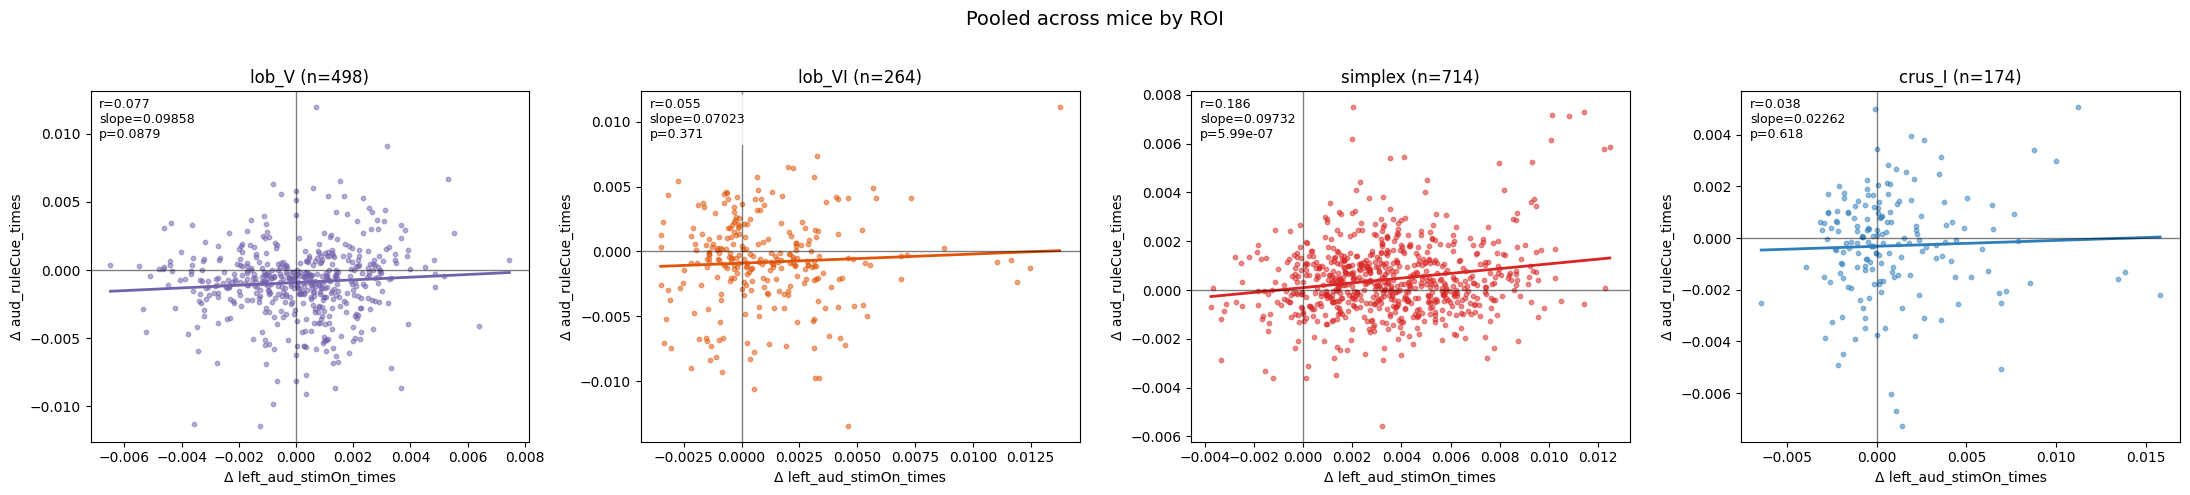

In [132]:
fig, results, pooled = plot_pooled_delta_scatter_by_roi(
    beta_all_A=beta_all_a,
    beta_all_B=beta_all_b,
    mouse_ids=mouse_ids,
    label_A=pred_a,
    label_B=pred_b,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=2,
    late_n=2,
    min_points=20
)

In [133]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_stim_resp_covary"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"contra_aud_vs_aud_ruleCue_beta.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"contra_aud_vs_aud_ruleCue_beta.png"),
                dpi=300, bbox_inches='tight')

In [ ]:
def early_late_delta_uev(uev_mat, early_n=3, late_n=3, require_full_windows=False):
    """
    uev_mat: (N_ids, N_days) with NaNs for missing

    Returns:
      delta: (N_ids,) late_mean - early_mean

    If require_full_windows=True:
      - requires all early_n days AND all late_n days to be finite for that neuron,
        else delta is NaN.
    """
    U = np.asarray(uev_mat, dtype=np.float32)
    if U.ndim != 2:
        raise ValueError(f"uev_mat must be 2D (N_ids, N_days); got shape {U.shape}")

    if U.shape[1] < (early_n + late_n):
        # still compute what we can, but warn via behavior rather than print
        pass

    early_block = U[:, :early_n]
    late_block  = U[:, -late_n:]

    if require_full_windows:
        early_ok = np.all(np.isfinite(early_block), axis=1)
        late_ok  = np.all(np.isfinite(late_block), axis=1)
        ok = early_ok & late_ok

        delta = np.full((U.shape[0],), np.nan, dtype=np.float32)
        if np.any(ok):
            early = np.mean(early_block[ok], axis=1)
            late  = np.mean(late_block[ok], axis=1)
            delta[ok] = late - early
        return delta

    # default: allow partial windows (nanmean)
    early = np.nanmean(early_block, axis=1)
    late  = np.nanmean(late_block, axis=1)
    return late - early


# ----------------------------
# Pool points by ROI across mice
# ----------------------------
def pooled_points_by_roi_uev(
    uev_all_A, uev_all_B, mouse_ids,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=3, late_n=3,
    require_full_windows=False,
):
    """
    Returns dict roi -> (x, y) pooled across mice, where:
      x = ΔUEV(A), y = ΔUEV(B)

    Expects per-mouse entries:
      uev_all_X[mouse]["uev"]  : (N_ids, N_days)
      uev_all_X[mouse]["meta"]["roi"] : (N_ids,)
    """
    pts = {r: ([], []) for r in roi_order}
    if include_unassigned:
        pts["unassigned"] = ([], [])

    for mouse in mouse_ids:
        UA = np.asarray(uev_all_A[mouse]["uev"])
        UB = np.asarray(uev_all_B[mouse]["uev"])
        if UA.shape != UB.shape:
            raise ValueError(f"{mouse}: A and B UEV matrices must match shape; got {UA.shape} vs {UB.shape}")

        roi = np.asarray(uev_all_A[mouse]["meta"].get("roi", None), dtype=object)
        if roi is None or roi.size == 0:
            raise ValueError(f"{mouse}: ROI labels missing in uev_all_A[mouse]['meta']['roi']")
        if roi.shape[0] != UA.shape[0]:
            raise ValueError(f"{mouse}: roi length must match N_ids; got {roi.shape[0]} vs {UA.shape[0]}")

        dA = early_late_delta_uev(UA, early_n=early_n, late_n=late_n, require_full_windows=require_full_windows)
        dB = early_late_delta_uev(UB, early_n=early_n, late_n=late_n, require_full_windows=require_full_windows)

        ok = np.isfinite(dA) & np.isfinite(dB)
        dA = dA[ok]
        dB = dB[ok]
        roi_ok = roi[ok]

        for rname in roi_order:
            m = (roi_ok == rname)
            if np.any(m):
                pts[rname][0].append(dA[m])
                pts[rname][1].append(dB[m])

        if include_unassigned:
            m = (roi_ok == None)
            if np.any(m):
                pts["unassigned"][0].append(dA[m])
                pts["unassigned"][1].append(dB[m])

    # concatenate
    out = {}
    for rname, (xs, ys) in pts.items():
        if len(xs) == 0:
            out[rname] = (np.array([]), np.array([]))
        else:
            out[rname] = (np.concatenate(xs), np.concatenate(ys))
    return out


# ----------------------------
# Pooled scatter + fit per ROI
# ----------------------------
def plot_pooled_delta_scatter_by_roi_uev(
    uev_all_A, uev_all_B, mouse_ids,
    label_A="Predictor A",
    label_B="Predictor B",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=3, late_n=3,
    require_full_windows=False,
    min_points=20,
    s=10,
    alpha=0.5,
    add_reference_lines=True,
):
    """
    For each ROI, plot pooled ΔUEV(A) vs ΔUEV(B) scatter across all mice, plus linear fit line.
    Prints fit stats and returns results dict.

    Returns:
      results: dict roi -> {'n','r','slope','intercept','p','stderr'}
      pooled:  dict roi -> (x, y)
    """
    pooled = pooled_points_by_roi_uev(
        uev_all_A, uev_all_B, mouse_ids,
        roi_order=roi_order,
        include_unassigned=include_unassigned,
        early_n=early_n, late_n=late_n,
        require_full_windows=require_full_windows,
    )

    results = {}
    rois = list(roi_order) + (["unassigned"] if include_unassigned else [])

    for roi_name in rois:
        x, y = pooled.get(roi_name, (np.array([]), np.array([])))
        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]
        n = x.size

        if n < min_points:
            results[roi_name] = {"n": int(n), "r": np.nan, "slope": np.nan, "intercept": np.nan,
                                 "p": np.nan, "stderr": np.nan}
            print(f"{roi_name:10s}: n={n} (skipped, need >= {min_points})")
            continue

        lr = stats.linregress(x, y)
        results[roi_name] = {
            "n": int(n),
            "r": float(lr.rvalue),
            "slope": float(lr.slope),
            "intercept": float(lr.intercept),
            "p": float(lr.pvalue),
            "stderr": float(lr.stderr) if lr.stderr is not None else np.nan,
        }

        # --- Plot ---
        plt.figure(figsize=(5.2, 5.2))
        plt.scatter(x, y, s=s, alpha=alpha)

        # fit line
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        xx = np.linspace(xmin, xmax, 200)
        yy = lr.intercept + lr.slope * xx
        plt.plot(xx, yy, linewidth=2)

        if add_reference_lines:
            plt.axhline(0, linewidth=1)
            plt.axvline(0, linewidth=1)

        plt.xlabel(f"Δ UEV {label_A} (late − early)")
        plt.ylabel(f"Δ UEV {label_B} (late − early)")
        plt.title(f"Pooled across mice — {roi_name}")

        txt = (
            f"n={n}\n"
            f"r={lr.rvalue:.3f}\n"
            f"slope={lr.slope:.4g}\n"
            f"p={lr.pvalue:.3g}"
        )
        ax = plt.gca()
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
        )

        plt.tight_layout()
        plt.show()

        print(
            f"{roi_name:10s}: n={n:5d}  r={lr.rvalue: .3f}  "
            f"slope={lr.slope: .4g}  p={lr.pvalue: .3g}"
        )

    return results, pooled


# ----------------------------
# Single-mouse scatter colored by ROI
# ----------------------------
def plot_delta_scatter_by_roi_uev(
    uev_all_A,
    uev_all_B,
    mouse,
    label_A="Predictor A",
    label_B="Predictor B",
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=3,
    late_n=3,
    require_full_windows=False,
    alpha=0.7,
    s=14,
):
    UA = np.asarray(uev_all_A[mouse]["uev"])
    UB = np.asarray(uev_all_B[mouse]["uev"])

    if UA.shape != UB.shape:
        raise ValueError("Predictor A and B UEV matrices must have same shape (N_ids, N_days)")

    roi = np.asarray(uev_all_A[mouse]["meta"].get("roi", None), dtype=object)
    if roi is None or roi.size == 0:
        raise ValueError("ROI labels not found in meta")
    if roi.shape[0] != UA.shape[0]:
        raise ValueError(f"ROI length must match N_ids; got {roi.shape[0]} vs {UA.shape[0]}")

    # compute deltas
    dA = early_late_delta_uev(UA, early_n=early_n, late_n=late_n, require_full_windows=require_full_windows)
    dB = early_late_delta_uev(UB, early_n=early_n, late_n=late_n, require_full_windows=require_full_windows)

    ok = np.isfinite(dA) & np.isfinite(dB)
    dA = dA[ok]
    dB = dB[ok]
    roi_ok = roi[ok]

    r = np.corrcoef(dA, dB)[0, 1] if dA.size > 2 else np.nan

    plt.figure(figsize=(5.2, 5.2))

    plotted = 0
    for rname in roi_order:
        m = (roi_ok == rname)
        if not np.any(m):
            continue
        plt.scatter(dA[m], dB[m], s=s, alpha=alpha, label=f"{rname} (n={m.sum()})")
        plotted += int(m.sum())

    if include_unassigned:
        m = (roi_ok == None)
        if np.any(m):
            plt.scatter(dA[m], dB[m], s=s, alpha=alpha, label=f"unassigned (n={m.sum()})")
            plotted += int(m.sum())

    plt.axhline(0, lw=1)
    plt.axvline(0, lw=1)

    plt.xlabel(f"Δ UEV {label_A} (late − early)")
    plt.ylabel(f"Δ UEV {label_B} (late − early)")
    plt.title(f"{mouse}: early–late ΔUEV by ROI (r={r:.2f}, n={plotted})")
    plt.legend(frameon=True, fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()

In [ ]:
pred_a = "vis_reward_times"   # <-- example

uev_all_a = {}
for mouse in mouse_ids:
    dates, uev, meta = combine_arms_uev_tensor_with_roi(
        agg_data, tracking_summary, mouse, pred_a,
        unique_predictors=unique_predictors,
        roi_masks_full=roi_masks_full,   # <-- your dict[str]->(H,W)
        roi_x_key='xcoord_atlas',        # or 'xcoord_lin'
        roi_y_key='ycoord_atlas',        # or 'ycoord_lin'
        roi_frac_thresh=0.2,
        use_kept=True
    )
    uev_all_a[mouse] = {"dates": dates, "uev": uev, "meta": meta}

pred_b = "face"   # <-- example
uev_all_b = {}
for mouse in mouse_ids:
    dates, uev, meta = combine_arms_uev_tensor_with_roi(
        agg_data, tracking_summary, mouse, pred_b,
        unique_predictors=unique_predictors,
        roi_masks_full=roi_masks_full,   # <-- your dict[str]->(H,W)
        roi_x_key='xcoord_atlas',        # or 'xcoord_lin'
        roi_y_key='ycoord_atlas',        # or 'ycoord_lin'
        roi_frac_thresh=0.2,
        use_kept=True
    )
    uev_all_b[mouse] = {"dates": dates, "uev": uev, "meta": meta}

C:\Users\dirk\AppData\Local\Temp\ipykernel_28660\2173408078.py:37: RuntimeWarning: Mean of empty slice
  late  = np.nanmean(late_block, axis=1)
C:\Users\dirk\AppData\Local\Temp\ipykernel_28660\2173408078.py:36: RuntimeWarning: Mean of empty slice
  early = np.nanmean(early_block, axis=1)


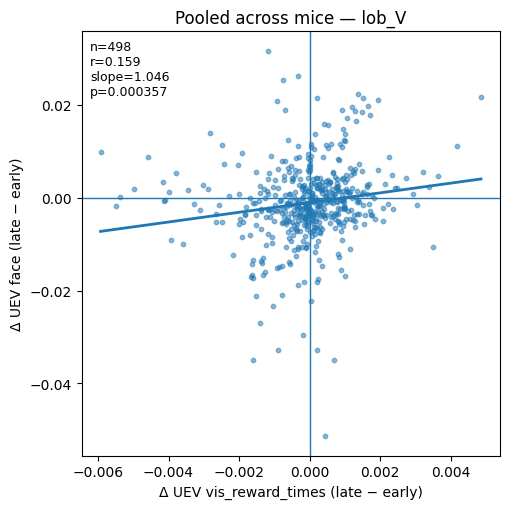

lob_V     : n=  498  r= 0.159  slope= 1.046  p= 0.000357


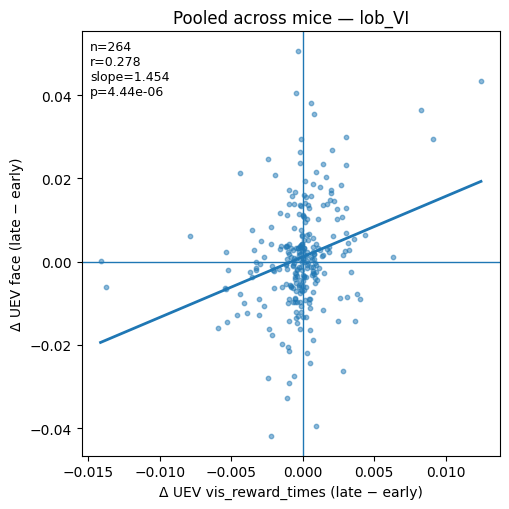

lob_VI    : n=  264  r= 0.278  slope= 1.454  p= 4.44e-06


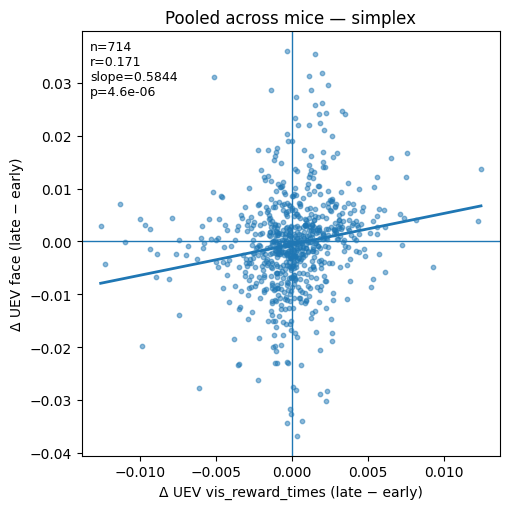

simplex   : n=  714  r= 0.171  slope= 0.5844  p= 4.6e-06


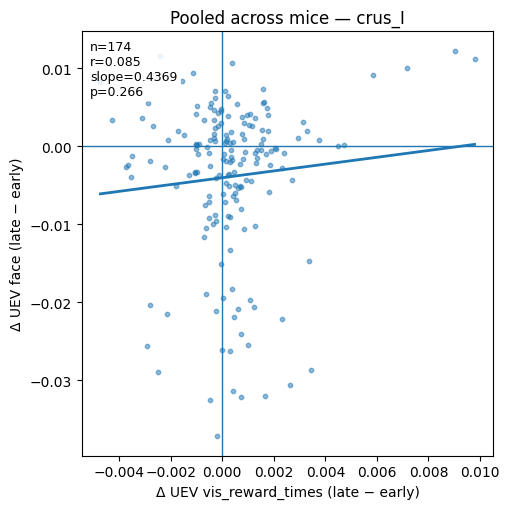

crus_I    : n=  174  r= 0.085  slope= 0.4369  p= 0.266


In [ ]:
results, pooled = plot_pooled_delta_scatter_by_roi_uev(
    uev_all_A=uev_all_a,
    uev_all_B=uev_all_b,
    mouse_ids=mouse_ids,
    label_A=pred_a,
    label_B=pred_b,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    include_unassigned=False,
    early_n=2,
    late_n=2,
    min_points=20
)

In [ ]:
def compute_group_uev_session(
    F,                  # (N_neurons, T)
    design_matrix,      # (T, P)
    ridge_model,        # array/list of length N_neurons, each a dict as above
    group_predictors    # list of *base* names, e.g. ['vis_left_choice_times', 'aud_left_choice_times']
):
    """
    Compute unique explained variance for a *group* of predictors
    (e.g., all lags of vis_left_choice_times + aud_left_choice_times)
    using a drop-group approach.

    F is assumed to be (N, T): neurons x time
    design_matrix is (T, P): time x predictors
    """

    N = len(ridge_model)
    predictors = ridge_model[0]['predictors']  # full shifted predictor names
    P = len(predictors)

    # ---- find indices of all shifted copies for the group ----
    # More strict: require that the predictor name *starts with* the base name
    # or contains it followed by an underscore.
    group_idx = []
    for j, pname in enumerate(predictors):
        for g in group_predictors:
            if g in pname:
                group_idx.append(j)
                break  # don't double-add if two bases match
    group_idx = np.array(sorted(set(group_idx)), dtype=int)
    #print(group_idx)

    if group_idx.size == 0:
        raise ValueError(f"No predictors found for group_predictors={group_predictors}")

    # ---- build beta/intercept arrays ----
    beta = np.zeros((N, P))
    intercepts = np.zeros(N)

    for i, cell in enumerate(ridge_model):
        beta[i, :] = cell['beta']              # (P,)
        intercepts[i] = cell['intercepts']     # scalar

    # ---- compute UEV for the group ----
    uev_group = np.zeros(N)

    # sanity on shapes
    # F: (N, T), design_matrix: (T, P)
    assert design_matrix.shape[1] == P, "Design matrix P mismatch with predictors"
    assert F.shape[1] == design_matrix.shape[0], "Time dimension mismatch between F and design_matrix"

    for i in range(N):
        y = F[i, :]                               # (T,)

        # full model
        y_hat_full = design_matrix @ beta[i, :] + intercepts[i]
        rss_full = np.sum((y - y_hat_full) ** 2)

        # reduced model: zero out all lags of the group predictors
        b_red = beta[i, :].copy()
        b_red[group_idx] = 0.0
        y_hat_red = design_matrix @ b_red + intercepts[i]
        rss_red = np.sum((y - y_hat_red) ** 2)

        # unique explained variance of the *group*
        uev_group[i] = (rss_red - rss_full) / rss_full

    return uev_group

In [ ]:
loaded = np.load(os.path.join(r'I:\Cerebellum_imaging_Dec2025', 'roi_polygons.npz'), allow_pickle=True)
roi_polygons = {k: loaded[k] for k in loaded.files}
tv = np.load(r'D:\Lab_Analysis\allenCCF\template_volume_10um.npy')
atlas_template = create_angled_slice(
        tv, 
        pitch_angle=15,  # 15 degrees nose down
        roll_angle=3,     # roll along ant-post axis, + rolls to the left
        slice_height=65
    )
atlas_template = atlas_template[999:1230, 199:940]
roi_masks_full = polygons_to_masks(roi_polygons, atlas_template.shape)

In [ ]:
agg_data = {}
behav_train_path = r'I:\Cerebellum_imaging_Dec2025\training_data'
ca_img_path = r'I:\Cerebellum_Imaging_Dec2025'
mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AF_L3', 'AB_R2', 'J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2'] 
#mouse_ids = ['AF_L3', 'AB_R2', 'A_R2', 'A_R3','J_L2', 'AF_L2'] 
# mouse_ids = ['J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        facemap_folder = os.path.join(bhv_path, 'raw_video_data')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            try:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm1'] = {}
            mouse_data[date]['arm1']['stat'] = np.array(arm1_stat, dtype=object)
            mouse_data[date]['arm1']['table_for_img'] = pd.read_csv(arm1_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm1']['design_matrix'] = np.load(os.path.join(arm1_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
            frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
            arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
            arm1_dff_for_video = arm1_dff[:,tf_arm1_table_for_img['ruleCue_times'][0]:tf_arm1_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm1']['design_matrix']    # (T, P)
            F = arm1_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm1']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new
            mouse_data[date]['arm1']['unique_predictors_extended'] = list(unique_predictors) + ['left_choice_group', 'right_choice_group']
        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            try:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm2'] = {}
            mouse_data[date]['arm2']['stat'] = np.array(arm2_stat, dtype=object)
            mouse_data[date]['arm2']['table_for_img'] = pd.read_csv(arm2_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm2']['design_matrix'] = np.load(os.path.join(arm2_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
            frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
            arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
            arm2_dff_for_video = arm2_dff[:,tf_arm2_table_for_img['ruleCue_times'][0]:tf_arm2_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm2']['design_matrix']    # (T, P)
            F = arm2_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm2']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new


        mouse_data[date]['pupil_area'] = np.load(os.path.join(facemap_folder, 'pupil_area.npy')) # synced to table for video
        mouse_data[date]['pupil_xpos'] = np.load(os.path.join(facemap_folder, 'pupil_xpos.npy'))
        mouse_data[date]['pupil_ypos'] = np.load(os.path.join(facemap_folder, 'pupil_ypos.npy'))
        mouse_data[date]['body_motion'] = np.load(os.path.join(facemap_folder, 'bodymotion_svd.npy'))
        mouse_data[date]['face_motion'] = np.load(os.path.join(facemap_folder, 'facemotion_svd.npy'))
        mouse_data[date]['lick'] = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
        mouse_data[date]['pupil_area'] = fill_nan_with_previous(mouse_data[date]['pupil_area'])
        mouse_data[date]['pupil_xpos'] = fill_nan_with_previous(mouse_data[date]['pupil_xpos'])
        mouse_data[date]['pupil_ypos'] = fill_nan_with_previous(mouse_data[date]['pupil_ypos'])
        mouse_data[date]['table_for_video'] = pd.read_csv(bhv_path+'\\table_for_video.csv')
        mouse_data[date]['trials_table'] = pd.read_parquet(bhv_path+'\\alf\\_ibl_trials.table.pqt')
        
        bpod_trials = rawio.load_data(bhv_path, task_collection='raw_behavior_data')
        ts, pos = get_wheel_position(bhv_path, bpod_trials, task_collection='raw_behavior_data')
        interp_pos, interp_ts = wh.interpolate_position(ts, pos, freq=1000)
        wheel_moves = extract_wheel_moves(ts, pos, display=False)
        mouse_data[date]['wheel_vel'] = extract_wheel_velocity(interp_pos) # synced to trials table
        mouse_data[date]['wheel_ts'] = interp_ts
        mouse_data[date]['wheel_pos'] = interp_pos
    
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:15]
    
    
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            if 'arm1' in mouse_data[date]:
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
                tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
                arm1_bsl_psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm1_bsl_psth = get_trial_PSTH(arm1_dff, arm1_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm1_bsl_psth = arm1_bsl_psth.reshape(arm1_bsl_psth.shape[0], -1)
                arm1_bsl_mean = np.mean(arm1_bsl_psth, axis=1)
                arm1_bsl_sd = np.std(arm1_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm1_bsl_mean[np.newaxis, :, np.newaxis]) / arm1_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
            if 'arm2' in mouse_data[date]:  
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy')) 
                tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
                arm2_bsl_psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm2_bsl_psth = get_trial_PSTH(arm2_dff, arm2_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm2_bsl_psth = arm2_bsl_psth.reshape(arm2_bsl_psth.shape[0], -1)
                arm2_bsl_mean = np.mean(arm2_bsl_psth, axis=1)
                arm2_bsl_sd = np.std(arm2_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm2_bsl_mean[np.newaxis, :, np.newaxis]) / arm2_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
    agg_data[mouse] = mouse_data
    

2026-03-04 10:06:48.673 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 117657  I:\Cerebellum_Imaging_Dec2025\AE_L2\20250729_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-03-04 10:09:06.876 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 113967  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250617_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-03-04 10:11:31.761 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 66038  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-03-04 10:11:31.765 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 177585  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_beha

In [135]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# -------------------------------
# Utility helpers
# -------------------------------

def rolling_average(x, w=3):
    x = np.asarray(x, dtype=float)
    if w <= 1 or x.size == 0:
        return x
    pad = np.pad(x, (w-1, 0), mode='edge')
    c = np.cumsum(pad)
    out = (c[w:] - c[:-w]) / w
    head = np.full(w-1, out[0])
    return np.concatenate([head, out])

def classify_day_stage(vis_perf, aud_perf, vis_raw, aud_raw, perf_thresh=0.65):
    """
    Returns: 'naive' | 'vis_expert' | 'aud_expert' | 'db_expert'
    Prefers rolling perf; falls back to raw day perf.
    """
    v = float(vis_perf) if np.isfinite(vis_perf) else float(vis_raw)
    a = float(aud_perf) if np.isfinite(aud_perf) else float(aud_raw)
    v_ok = (v > perf_thresh) or (vis_raw > perf_thresh)
    a_ok = (a > perf_thresh) or (aud_raw > perf_thresh)
    if v_ok and a_ok:   return 'db_expert'
    if v_ok and not a_ok: return 'vis_expert'
    if a_ok and not v_ok: return 'aud_expert'
    return 'naive'

def robust_symmetric_clim(maps, pct=99.0, fallback=0.01):
    vals = []
    for m in maps:
        if m is None: 
            continue
        v = m[np.isfinite(m)]
        if v.size:
            vals.append(np.abs(v).ravel())
    if not vals:
        return (-fallback, fallback)
    allabs = np.concatenate(vals)
    lim = np.percentile(allabs, pct)
    lim = max(lim, fallback)
    return (-lim, lim)

# -------------------------------
# Rasterization (per-pixel) bins
# -------------------------------

def _bin_edges_from_extent(xlim, ylim, binsize):
    nbx = max(2, int(np.ceil((xlim[1] - xlim[0]) / binsize)))
    nby = max(2, int(np.ceil((ylim[1] - ylim[0]) / binsize)))
    xedges = np.linspace(xlim[0], xlim[1], nbx+1)
    yedges = np.linspace(ylim[0], ylim[1], nby+1)
    return xedges, yedges, nbx, nby

def rasterize_dendrites_full_atlas(
    neurons,
    atlas_shape,              # (H, W) from atlas_template.shape
    downsample=4,
    min_count=10,
    smooth_sigma_bins=1.0,
    weighting='length'        # 'length' | 'unit' | 'none'
):
    """
    Rasterizes dendrite pixels over the FULL atlas (0..W, 0..H) on a downsampled grid.
    Returns:
      H_mean (ny_ds, nx_ds), H_count (ny_ds, nx_ds), extent=[0,W,0,H]
    """
    H, W = map(int, atlas_shape)
    assert H > 0 and W > 0

    # downsampled grid size
    nx_ds = (W + downsample - 1) // downsample
    ny_ds = (H + downsample - 1) // downsample
    nb = nx_ds * ny_ds

    H_count_flat = np.zeros(nb, dtype=np.float32)
    H_sum_flat   = np.zeros(nb, dtype=np.float32)

    inv_ds = 1.0 / float(downsample)

    for neu in neurons:
        x = np.asarray(neu['xcoord_atlas']).ravel().astype(np.int64)  # columns
        y = np.asarray(neu['ycoord_atlas']).ravel().astype(np.int64)  # rows
        d = float(neu['data'])
        if x.size == 0 or y.size == 0 or not np.isfinite(d):
            continue

        # Clip to full atlas bounds
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue
        x = x[ok]; y = y[ok]

        # Downsampled bin indices in full field
        ix_ds = (x * inv_ds).astype(np.int64)  # 0..nx_ds-1
        iy_ds = (y * inv_ds).astype(np.int64)  # 0..ny_ds-1
        lin = (iy_ds * nx_ds + ix_ds)

        # Unique bins hit by this neuron + pixel counts
        u, c = np.unique(lin, return_counts=True)

        if weighting == 'unit':
            total = c.sum()
            wcounts = (c / total).astype(np.float32) if total > 0 else np.zeros_like(c, dtype=np.float32)
        elif weighting == 'none':
            wcounts = np.ones_like(c, dtype=np.float32)
        else:  # 'length'
            wcounts = c.astype(np.float32)

        H_count_flat[u] += wcounts
        H_sum_flat[u]   += wcounts * d

    with np.errstate(invalid='ignore', divide='ignore'):
        H_mean_flat = H_sum_flat / H_count_flat

    H_count = H_count_flat.reshape(ny_ds, nx_ds)
    H_mean  = H_mean_flat.reshape(ny_ds, nx_ds)

    # Mask sparse bins
    H_mean[H_count < min_count] = np.nan

    # Optional smoothing preserving NaNs
    if smooth_sigma_bins and smooth_sigma_bins > 0:
        mask = np.isfinite(H_mean)
        Hf = np.where(mask, H_mean, 0.0)
        wf = gaussian_filter(mask.astype(float), smooth_sigma_bins, mode='nearest')
        hf = gaussian_filter(Hf, smooth_sigma_bins, mode='nearest')
        H_mean = np.where(wf > 1e-9, hf / wf, np.nan)

    extent = [0, W, 0, H]
    return H_mean, H_count, extent


def make_stage_maps_rasterized_full_atlas(
    agg_data,
    mouse_ids,
    atlas_template,               # 2D background image
    pred_name,
    unique_predictors,
    full_predictors,
    perf_thresh=0.65,
    downsample=4,                 # spatial downsample factor
    smooth_sigma_bins=1.0,
    min_count=10,
    zscore_within_session=False,
    frame_reduction='mean',       # 'mean' or 'sum' across predictor lags
    weighting='length',            # 'length'|'unit'|'none'
    data_type='beta',
    clim = (-0.02, 0.02)
):
    """
    2x2 stage maps on the FULL atlas field using per-pixel rasterization.
    """
    
    unique_pred_idx = unique_predictors.index(pred_name)
    H, W = atlas_template.shape
    pooled = {k: [] for k in ['naive','vis_expert','aud_expert','db_expert']}

    for mouse in mouse_ids:
        md = agg_data[mouse]
        vis_acc = np.asarray(md['training']['accuracies_vis'])
        aud_acc = np.asarray(md['training']['accuracies_aud'])
        tr_dates = np.asarray(md['training']['training_dates'])
        vis_roll = rolling_average(vis_acc, w=3)
        aud_roll = rolling_average(aud_acc, w=3)

        img_dates = [s for s in md.keys() if (s.isdigit()
                   or (s.endswith('_valvesilent') and s.replace('_valvesilent','').isdigit())
                   or (s.endswith('_valvesilent_punishsilent') and s.replace('_valvesilent_punishsilent','').isdigit()))]

        for date in img_dates:
            #print('Aggregating mouse ' + mouse + ' date: ' + date + '...')
            if 'valvesilent' not in date and 'reward' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for reward...')
                continue
            if 'punishsilent' not in date and 'punish' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for punish...')
                continue
            idx = np.where(tr_dates == date[:8])[0]
            if idx.size == 0:
                continue
            di = int(idx[0])
            stage = classify_day_stage(vis_roll[di], aud_roll[di], vis_acc[di], aud_acc[di], perf_thresh)

            session_neurons, session_data = [], []
            for arm in ['arm1','arm2']:
                if arm not in md[date]:
                    continue
                for neuron in md[date][arm]['stat']:
                    if data_type == 'beta':
                        pred_idx = [i for i, nm in enumerate(predictors) if pred_name in nm]
                        if not pred_idx:
                            raise ValueError(f"Predictor '{pred_name}' not found in predictors list.")
                        beta_arr = np.asarray(neuron['beta'])[pred_idx].reshape(-1)
                        d = float(np.nanmean(beta_arr)) if frame_reduction == 'mean' else float(np.nansum(beta_arr))
                    elif data_type == 'r2':
                        d = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = neuron['bootstrap_p_value'][unique_pred_idx]
                    if p_value > 0.05:
                        d = 0
                    x = np.asarray(neuron['xcoord_atlas']).ravel()
                    y = np.asarray(neuron['ycoord_atlas']).ravel()
                    if x.size == 0 or y.size == 0 or not np.isfinite(d):
                        continue

                    session_neurons.append({'xcoord_atlas': x, 'ycoord_atlas': y, 'data': d})
                    session_data.append(d)

            if not session_neurons:
                continue

            if zscore_within_session:
                sb = np.asarray(session_data, dtype=float)
                mu = np.nanmean(sb); sd = np.nanstd(sb)
                zsb = np.zeros_like(sb) if (not np.isfinite(sd) or sd == 0.0) else (sb - mu) / sd
                for i in range(len(session_neurons)):
                    session_neurons[i]['data'] = float(zsb[i])

            pooled[stage].extend(session_neurons)

    # Build maps per stage on the FULL atlas
    stage_maps = {}
    extent = [0, W, 0, H]
    for stage in ['naive','vis_expert','aud_expert','db_expert']:
        print('build map for ' + stage + '...')
        neurons = pooled[stage]
        if not neurons:
            stage_maps[stage] = None
            continue
        H_mean, H_count, _ = rasterize_dendrites_full_atlas(
            neurons=neurons,
            atlas_shape=atlas_template.shape,
            downsample=downsample,
            min_count=min_count,
            smooth_sigma_bins=smooth_sigma_bins,
            weighting=weighting
        )
        stage_maps[stage] = H_mean

    # Color limits shared across panels
    #vmin, vmax = robust_symmetric_clim([stage_maps[s] for s in stage_maps], pct=99.0, fallback=0.01)
    if data_type == 'beta':
        vmin, vmax = clim
    elif data_type == 'r2':
        vmin, vmax = clim

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    panel_order  = ['naive','vis_expert','aud_expert','db_expert']
    panel_titles = ['Naive','Vis expert','Aud expert','Double expert']
    im_last = None

    for ax, stg, title in zip(axes.ravel(), panel_order, panel_titles):
        ax.imshow(atlas_template, cmap='gray', extent=[0, W, 0, H], origin='upper')
        Hm = stage_maps[stg]
        if Hm is not None:
            im_last = ax.imshow(
                Hm, cmap='coolwarm', vmin=vmin, vmax=vmax,
                extent=extent, origin='upper', alpha=0.9, interpolation='nearest'
            )
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(title, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])

    if im_last is not None:
        cbar = fig.colorbar(im_last, ax=axes.ravel().tolist(), shrink=0.8)
        cbar.set_label(f"Mean β for '{pred_name}'" + (" (z-scored per session)" if zscore_within_session else ""), rotation=90)

    return fig, axes, stage_maps, extent

In [136]:
def downsample_mask(mask, downsample):
    """
    mask: (H, W) boolean
    downsample: same factor as used for rasterize_dendrites_full_atlas
    Returns: ds_mask (ny_ds, nx_ds) boolean
             True if any full-res pixel in that bin is inside ROI.
    """
    H, W = mask.shape
    ny_ds = (H + downsample - 1) // downsample
    nx_ds = (W + downsample - 1) // downsample
    ds_mask = np.zeros((ny_ds, nx_ds), dtype=bool)

    for iy in range(ny_ds):
        for ix in range(nx_ds):
            y0 = iy * downsample
            y1 = min((iy + 1) * downsample, H)
            x0 = ix * downsample
            x1 = min((ix + 1) * downsample, W)
            patch = mask[y0:y1, x0:x1]
            if patch.size > 0 and patch.any():
                ds_mask[iy, ix] = True
    return ds_mask

def make_downsampled_roi_masks(roi_masks_full, downsample):
    """
    roi_masks_full: dict roi_name -> mask (H,W)
    Returns: dict roi_name -> ds_mask (ny_ds, nx_ds)
    """
    ds_masks = {}
    for name, m in roi_masks_full.items():
        ds_masks[name] = downsample_mask(m, downsample)
    return ds_masks

In [137]:
def estimate_roi_angle_from_mask(roi_mask_ds, downsample, mode='long_axis'):
    """
    roi_mask_ds: 2D boolean (ny_ds, nx_ds) in downsampled atlas coordinates
    downsample: factor used in rasterize_dendrites_full_atlas

    Returns angle_deg such that the principal axis is at angle_deg
    in atlas coordinates, where x increases to the right, y increases down.
    """
    ys, xs = np.where(roi_mask_ds)
    if xs.size == 0:
        return 0.0

    # Convert to atlas pixel coordinates (same as in compute_roi_profiles_from_maps)
    y_atlas = (ys + 0.5) * downsample
    x_atlas = (xs + 0.5) * downsample

    X = np.stack([x_atlas, y_atlas], axis=1)  # shape (N, 2)
    Xc = X - X.mean(axis=0, keepdims=True)

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    principal_vec = Vt[0]  # (vx, vy), unit vector along longest axis

    vx, vy = principal_vec
    angle_rad = np.arctan2(vy, vx)  # radians
    angle_deg = np.degrees(angle_rad)

    # If you want the "stripe" to be roughly horizontal or vertical
    # you can flip the sign / add 90° here based on convention.
    if mode == 'orthogonal':
        angle_deg = angle_deg + 90.0

    return angle_deg

def compute_roi_profiles_along_axis(
    stage_maps,
    roi_masks_ds,
    downsample,
    atlas_shape,
    roi_angles_deg=None,       # dict roi_name -> CW rotation angle (deg)
    bin_width_pixels=None,
    voxel_size_um=10.0
):
    """
    Compute 1D profiles along the 'ML' axis in a rotated view of each ROI.

    Interpretation:
      - angle_deg is how much you conceptually rotate the ROI mask CLOCKWISE.
      - After this rotation, we take HORIZONTAL bins (x' axis) in that rotated view.
      - This corresponds to:
          x' = x*cos(theta) + y*sin(theta)
        where (x, y) are atlas coordinates (ML, AP).

    Returns:
      profiles[roi_name][stage]['diag'] = (coords_mm, vals)
          coords_mm: distance along rotated horizontal axis (mm), starting at 0
      diag_angles[roi_name] = angle_deg actually used
    """
    H, W = atlas_shape
    profiles = {name: {} for name in roi_masks_ds.keys()}
    diag_angles = {}

    if bin_width_pixels is None:
        bin_width_pixels = downsample

    for roi_name, roi_mask in roi_masks_ds.items():
        ys, xs = np.where(roi_mask)
        if xs.size == 0:
            continue

        # atlas coordinates of pixel centers in original frame
        y_atlas = (ys + 0.5) * downsample
        x_atlas = (xs + 0.5) * downsample

        # --- rotation angle: how much you rotate the mask CW ---
        if roi_angles_deg is not None and roi_name in roi_angles_deg:
            angle_deg = float(roi_angles_deg[roi_name])
        else:
            # default: no rotation if angle not provided
            angle_deg = 0.0
        diag_angles[roi_name] = angle_deg

        angle_rad = np.deg2rad(angle_deg)

        # -------------------------------------------------------
        # Define horizontal axis in the rotated view (image coords, y down):
        # If you *visually* rotate the mask CLOCKWISE by theta,
        # the new horizontal axis x' in original (x,y) has:
        #   x' = x*cos(theta) - y*sin(theta)
        # -------------------------------------------------------
        ux = np.cos(angle_rad)
        uy = -np.sin(angle_rad)

        # initial projection onto rotated-horizontal axis
        s = x_atlas * ux + y_atlas * uy

        # -------------------------------------------------------
        # Fix direction so s increases roughly with x (left→right)
        # -------------------------------------------------------
        if np.corrcoef(s, x_atlas)[0, 1] < 0:
            ux, uy = -ux, -uy
            s = x_atlas * ux + y_atlas * uy

        # -------------------------------------------------------
        # Start axis at 0 on one edge of the ROI
        # -------------------------------------------------------
        s_min = s.min()
        s_rel = s - s_min
        s_max = s_rel.max()

        nbins = max(1, int(np.ceil(s_max / bin_width_pixels)))
        edges = np.linspace(0.0, s_max, nbins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # convert to mm
        centers_um = centers * voxel_size_um
        centers_mm = centers_um / 1000.0

        # -------------------------------------------------------
        # Build profiles for each stage
        # -------------------------------------------------------
        for stage, Hm in stage_maps.items():
            if Hm is None:
                continue
            assert Hm.shape == roi_mask.shape, "stage_map and ROI mask shape mismatch"

            vals = Hm[ys, xs]  # values inside ROI for this stage
            bin_idx = np.digitize(s_rel, edges) - 1

            prof_vals = np.full(nbins, np.nan)
            for b in range(nbins):
                mask_b = (bin_idx == b)
                if np.any(mask_b):
                    prof_vals[b] = np.nanmean(vals[mask_b])

            if stage not in profiles[roi_name]:
                profiles[roi_name][stage] = {}
            profiles[roi_name][stage]['diag'] = (centers_mm, prof_vals)

    return profiles, diag_angles

In [138]:
def plot_roi_profiles(
    profiles, roi_name, axis='AP',
    stages=('naive','vis_expert','aud_expert','db_expert'),
    ax=None, title_prefix='', perc=False, ylim=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    colors = {
        'naive': '#A0A0A0',
        'vis_expert': '#4E79A7',
        'aud_expert': '#F28E2B',
        'db_expert': '#59A14F'
    }

    voxel_size_um = 10.0
    bregma_AP_idx = 540
    midline_ML_idx = 335

    roi_prof = profiles.get(roi_name, {})

    for stg in stages:
        if stg not in roi_prof or axis not in roi_prof[stg]:
            continue
        coords, vals = roi_prof[stg][axis]

        if axis == 'AP':
            coords_um = (coords + 999) * voxel_size_um
            coords_rel_bregma_mm = (coords_um - bregma_AP_idx * voxel_size_um) / 1000
            coords_to_plot = coords_rel_bregma_mm
            xlabel = 'AP (mm from bregma)'
        elif axis == 'ML':
            coords_um = (coords - midline_ML_idx) * voxel_size_um
            coords_rel_mm = coords_um / 1000
            coords_to_plot = coords_rel_mm
            xlabel = 'ML (mm from midline)'
        elif axis == 'diag':
            # coords are already in mm along rotated horizontal axis, from 0
            coords_to_plot = coords
            xlabel = 'Distance across stripes (mm from 0)'
            # or: xlabel = 'ML (mm in rotated frame)'
        else:
            raise ValueError(f"Unknown axis type '{axis}'")

        yvals = vals * 100 if perc else vals
        ax.plot(coords_to_plot, yvals, label=stg, color=colors.get(stg, None), lw=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean value (%)' if perc else 'Mean value')

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(f"{title_prefix}{roi_name} – {axis}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    return ax

In [139]:
from scipy.ndimage import rotate
def plot_rotated_roi_mask(roi_mask_ds, angle_deg, ax=None, title=None):
    """
    Rotate the ROI mask so that its principal (stripe) axis becomes horizontal
    and plot it for sanity check.

    roi_mask_ds : 2D boolean in downsampled atlas space
    angle_deg   : angle of stripe axis in original space (same as diag_angles[roi])
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))

    # Convert to float for rotate, then back to bool
    # Rotate by -angle to align stripe axis with horizontal
    rotated = rotate(
        roi_mask_ds.astype(float),
        angle=-angle_deg,
        reshape=True,   # keep full rotated extent
        order=0         # nearest-neighbor
    ) > 0.5

    ax.imshow(rotated, cmap='gray', origin='upper')
    ax.set_xticks([]); ax.set_yticks([])
    if title is None:
        title = f"Rotated ROI (−{angle_deg:.1f}°)"
    ax.set_title(title)
    return ax

In [140]:
downsample = 2  # same as in make_stage_maps_rasterized_full_atlas
roi_masks_ds = make_downsampled_roi_masks(roi_masks_full, downsample)

In [141]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [146]:
# pred_name = unique_predictors[:15]  # e.g., 'stim_onset', 'choice_left', ...
for pred_name in unique_predictors[3:4]:
    fig, axes, stage_maps, extent = make_stage_maps_rasterized_full_atlas(
        agg_data=agg_data,
        mouse_ids=mouse_ids,
        atlas_template=atlas_template,
        pred_name=pred_name,
        unique_predictors=unique_predictors,
        full_predictors=predictors,
        perf_thresh=0.65,
        downsample=2,                # try 8 for speed, 2 for detail
        smooth_sigma_bins=1.0,
        min_count=30,                # bump a bit if downsample is small
        zscore_within_session=False,
        frame_reduction='mean',
        weighting='length' ,          # or 'unit' to equalize per-neuron contribution
        data_type='r2',
        clim = (-0.04, 0.04)
    )

    #out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2_topo'
    svg_out_dir = r'I:\Cerebellum_imaging_Dec2025\pub_fig\FigSupp_ipsilat_sensory_stim'
    # os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(svg_out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.png"),
                dpi=300, bbox_inches='tight')
    fig.savefig(
        os.path.join(svg_out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.svg"),
        format='svg',
        dpi=300,
        bbox_inches='tight',
        transparent=True,   # optional: removes white background
        metadata={'Creator': 'Matplotlib'}
    )
    plt.close(fig)
    rotation_angle = {'lob_V':0, 'lob_VI':0, 'simplex':40, 'crus_I':40}
    rot_profiles, angles = compute_roi_profiles_along_axis(
                stage_maps=stage_maps,
                roi_masks_ds=roi_masks_ds,
                downsample=downsample,
                atlas_shape=atlas_template.shape,
                roi_angles_deg=rotation_angle,      # auto-PCA per ROI
                bin_width_pixels=downsample
            )
    roi_list = ['lob_V', 'lob_VI', 'simplex', 'crus_I']
    
    fig, axes = plt.subplots(2, 2, figsize=(6, 4), sharey=True)
    for ax, roi_name in zip(axes.ravel(), roi_list):
        ax = plot_roi_profiles(rot_profiles, ax=ax, roi_name=roi_name, axis='diag', 
                    title_prefix='angle:' + f'{angles[roi_name]:.1f}', ylim=(-0.001, 0.021))
    plt.tight_layout()
    # out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2_roi_profiles'
    # os.makedirs(out_dir, exist_ok=True)
    fig.savefig(
        os.path.join(svg_out_dir, f"diag_roi_profiles_{pred_name.replace(' ','_')}.svg"),
        format='svg',
        dpi=300,
        bbox_inches='tight',
        transparent=True,   # optional: removes white background
        metadata={'Creator': 'Matplotlib'}
    )
    fig.savefig(
        os.path.join(svg_out_dir, f"diag_roi_profiles_{pred_name.replace(' ','_')}.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)

build map for naive...


C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\1977767479.py:133: RuntimeWarning: invalid value encountered in divide
  H_mean = np.where(wf > 1e-9, hf / wf, np.nan)


build map for vis_expert...
build map for aud_expert...
build map for db_expert...


C:\Users\dirk\AppData\Local\Temp\ipykernel_31068\3775377582.py:134: RuntimeWarning: Mean of empty slice
  prof_vals[b] = np.nanmean(vals[mask_b])
